In [181]:
# =========================
# NUMERICAL COMPUTING
# =========================
import numpy as np
import pandas as pd

# =========================
# DATA VISUALIZATION
# =========================
import matplotlib.pyplot as plt
import seaborn as sns

# =========================
# SCIKIT-LEARN UTILITIES
# =========================
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    StratifiedKFold,
    GridSearchCV,
    RandomizedSearchCV
)

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    mean_squared_error,
    mean_absolute_error,
    r2_score
)

# =========================
# DATA PREPROCESSING
# =========================
from sklearn.preprocessing import (
    StandardScaler,
    MinMaxScaler,
    RobustScaler,
    LabelEncoder,
    OneHotEncoder
)

from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# =========================
# FEATURE SELECTION
# =========================
from sklearn.feature_selection import (
    SelectKBest,
    chi2,
    f_classif,
    mutual_info_classif
)

# =========================
# CLASSIFICATION MODELS
# =========================
from sklearn.linear_model import LogisticRegression

from sklearn.neighbors import KNeighborsClassifier

from sklearn.svm import SVC

from sklearn.tree import DecisionTreeClassifier

from sklearn.naive_bayes import (
    GaussianNB,
    MultinomialNB
)

from sklearn.ensemble import (
    RandomForestClassifier,
    ExtraTreesClassifier,
    GradientBoostingClassifier,
    AdaBoostClassifier
)

# =========================
# REGRESSION MODELS
# =========================
from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.tree import DecisionTreeRegressor

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor,
    AdaBoostRegressor,
    ExtraTreesRegressor
)

from sklearn.svm import SVR

from sklearn.neighbors import KNeighborsRegressor

# =========================
# CLUSTERING
# =========================
from sklearn.cluster import (
    KMeans,
    DBSCAN,
    AgglomerativeClustering
)

# =========================
# DIMENSIONALITY REDUCTION
# =========================
from sklearn.decomposition import PCA

# =========================
# ENSEMBLE LEARNING
# =========================
from sklearn.ensemble import (
    VotingClassifier,
    VotingRegressor,
    BaggingClassifier,
    BaggingRegressor,
    StackingClassifier,
    StackingRegressor
)

# =========================
# BOOSTING LIBRARIES
# =========================
from xgboost import XGBClassifier, XGBRegressor
from lightgbm import LGBMClassifier, LGBMRegressor
from catboost import CatBoostClassifier, CatBoostRegressor

# =========================
# WARNINGS
# =========================
import warnings
warnings.filterwarnings("ignore")

In [182]:
df_bureau = pd.read_csv('bureau_data.csv')
df_customers = pd.read_csv('customers.csv')
df_loans = pd.read_csv('loans.csv')

## BUREAU

In [183]:
df_bureau

,cust_id,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,1,1,42,0,0,3,7
1,C00002,3,1,96,12,60,5,4
2,C00003,2,1,82,24,147,6,58
3,C00004,3,0,115,15,87,5,26
4,C00005,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...
49995,C49996,4,2,165,1,6,8,24
49996,C49997,4,0,161,0,0,4,91
49997,C49998,4,1,42,0,0,7,38
49998,C49999,1,2,42,9,47,4,17


In [184]:
df_bureau.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   cust_id                    50000 non-null  object
 1   number_of_open_accounts    50000 non-null  int64 
 2   number_of_closed_accounts  50000 non-null  int64 
 3   total_loan_months          50000 non-null  int64 
 4   delinquent_months          50000 non-null  int64 
 5   total_dpd                  50000 non-null  int64 
 6   enquiry_count              50000 non-null  int64 
 7   credit_utilization_ratio   50000 non-null  int64 
dtypes: int64(7), object(1)
memory usage: 3.1+ MB


In [185]:
df_bureau.isna().sum()

cust_id                      0
number_of_open_accounts      0
number_of_closed_accounts    0
total_loan_months            0
delinquent_months            0
total_dpd                    0
enquiry_count                0
credit_utilization_ratio     0
dtype: int64

In [186]:
df_bureau.describe()

,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
count,50000.000000,50000.00000,50000.000000,50000.00000,50000.000000,50000.000000,50000.00000
mean,2.500140,1.00106,76.127140,4.87890,26.858000,5.009340,43.36142
std,1.118725,0.81412,43.762469,5.85032,32.832832,2.029122,29.35598
min,1.000000,0.00000,1.000000,0.00000,0.000000,1.000000,0.00000
25%,1.000000,0.00000,42.000000,0.00000,0.000000,4.000000,18.00000
50%,3.000000,1.00000,71.000000,3.00000,14.000000,5.000000,39.00000
75%,4.000000,2.00000,107.000000,9.00000,46.000000,6.000000,67.00000
max,4.000000,2.00000,223.000000,24.00000,171.000000,9.000000,99.00000


In [187]:
df_bureau.duplicated().sum()

np.int64(0)

## CUSTOMERS


In [188]:
df_customers

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,state,zipcode
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,Delhi,110001
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,Tamil Nadu,600001
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,West Bengal,700001
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,Karnataka,560001
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,Maharashtra,411001
...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,Tamil Nadu,600001
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,West Bengal,700001
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,Karnataka,560001
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,Telangana,500001


In [189]:
df_customers.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 12 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   cust_id                   50000 non-null  object
 1   age                       50000 non-null  int64 
 2   gender                    50000 non-null  object
 3   marital_status            50000 non-null  object
 4   employment_status         50000 non-null  object
 5   income                    50000 non-null  int64 
 6   number_of_dependants      50000 non-null  int64 
 7   residence_type            49938 non-null  object
 8   years_at_current_address  50000 non-null  int64 
 9   city                      50000 non-null  object
 10  state                     50000 non-null  object
 11  zipcode                   50000 non-null  int64 
dtypes: int64(5), object(7)
memory usage: 4.6+ MB


In [190]:
df_customers.isna().sum()

cust_id                      0
age                          0
gender                       0
marital_status               0
employment_status            0
income                       0
number_of_dependants         0
residence_type              62
years_at_current_address     0
city                         0
state                        0
zipcode                      0
dtype: int64

In [191]:
df_customers.describe()

,age,income,number_of_dependants,years_at_current_address,zipcode
count,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000
mean,39.550980,2.640898e+06,1.939540,16.018440,419090.860000
std,9.847752,2.629441e+06,1.535517,8.926489,168982.674047
min,18.000000,0.000000e+00,0.000000,1.000000,110001.000000
25%,33.000000,8.030000e+05,0.000000,8.000000,302001.000000
50%,40.000000,1.892000e+06,2.000000,16.000000,400001.000000
75%,46.000000,3.332250e+06,3.000000,24.000000,560001.000000
max,70.000000,1.199900e+07,5.000000,31.000000,700001.000000


In [192]:
df_customers.duplicated().sum()

np.int64(0)

## LOANS


In [193]:
df_loans

,loan_id,cust_id,loan_purpose,loan_type,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,L00001,C00001,Auto,Secured,3004000,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,L00002,C00002,Home,Secured,4161000,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,L00003,C00003,Personal,Unsecured,2401000,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,L00004,C00004,Personal,Unsecured,2345000,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,L00005,C00005,Auto,Secured,4647000,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,L49996,C49996,Personal,Unsecured,610000,535000,10700.0,96300,428000,22,385199,178470,2024-07-22,2024-08-15,False
49996,L49997,C49997,Auto,Secured,4211000,3243000,64860.0,583740,2594400,15,1656484,1040735,2024-07-22,2024-07-29,False
49997,L49998,C49998,Home,Secured,4097000,3740000,74800.0,673200,2992000,37,912691,355461,2024-07-22,2024-07-25,False
49998,L49999,C49999,Home,Secured,1871000,1630000,32600.0,293400,1304000,37,300035,179453,2024-07-22,2024-07-29,False


In [194]:
df_loans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   loan_id                      50000 non-null  object 
 1   cust_id                      50000 non-null  object 
 2   loan_purpose                 50000 non-null  object 
 3   loan_type                    50000 non-null  object 
 4   sanction_amount              50000 non-null  int64  
 5   loan_amount                  50000 non-null  int64  
 6   processing_fee               50000 non-null  float64
 7   gst                          50000 non-null  int64  
 8   net_disbursement             50000 non-null  int64  
 9   loan_tenure_months           50000 non-null  int64  
 10  principal_outstanding        50000 non-null  int64  
 11  bank_balance_at_application  50000 non-null  int64  
 12  disbursal_date               50000 non-null  object 
 13  installment_star

In [195]:
df_loans.isna().sum()

loan_id                        0
cust_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
default                        0
dtype: int64

In [196]:
df_loans.describe()

,sanction_amount,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application
count,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,5.000000e+04,50000.000000,5.000000e+04,5.000000e+04
mean,4.704828e+06,3.999679e+06,8.049471e+04,7.199422e+05,3.199743e+06,25.940520,1.337636e+06,9.891264e+05
std,6.267276e+06,5.376552e+06,1.173123e+05,9.677794e+05,4.301242e+06,12.433163,1.214714e+06,1.046072e+06
min,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.000000,-1.000000e+00,0.000000e+00
25%,1.147000e+06,9.670000e+05,1.934000e+04,1.740600e+05,7.736000e+05,16.000000,4.247990e+05,2.870075e+05
50%,2.656000e+06,2.240000e+06,4.480000e+04,4.032000e+05,1.792000e+06,24.000000,1.002309e+06,6.685250e+05
75%,5.172250e+06,4.611000e+06,9.224000e+04,8.299800e+05,3.688800e+06,35.000000,1.790751e+06,1.238667e+06
max,5.217500e+07,4.781900e+07,5.698030e+06,8.607420e+06,3.825520e+07,59.000000,5.000000e+06,7.846643e+06


In [197]:
df_loans.duplicated().sum()

np.int64(0)

### MERGE AND EDA


In [198]:
df = pd.merge(df_customers,df_loans,on='cust_id')
df.head()

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,loan_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,disbursal_date,installment_start_dt,default
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2467000,49340.0,444060,1973600,33,1630408,873386,2019-07-24,2019-08-10,False
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,3883000,77660.0,698940,3106400,30,709309,464100,2019-07-24,2019-08-15,False
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2170000,43400.0,390600,1736000,21,1562399,1476042,2019-07-24,2019-08-21,False
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,1747000,34940.0,314460,1397600,6,1257839,1031094,2019-07-24,2019-08-09,False
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,4520000,90400.0,813600,3616000,28,1772334,1032458,2019-07-24,2019-08-02,False


In [199]:
df = pd.merge(df,df_bureau)
df

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,default,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio
0,C00001,44,M,Married,Self-Employed,2586000,3,Owned,27,Delhi,...,2019-07-24,2019-08-10,False,1,1,42,0,0,3,7
1,C00002,38,M,Married,Salaried,1206000,3,Owned,4,Chennai,...,2019-07-24,2019-08-15,False,3,1,96,12,60,5,4
2,C00003,46,F,Married,Self-Employed,2878000,3,Owned,24,Kolkata,...,2019-07-24,2019-08-21,False,2,1,82,24,147,6,58
3,C00004,55,F,Single,Self-Employed,3547000,1,Owned,15,Bangalore,...,2019-07-24,2019-08-09,False,3,0,115,15,87,5,26
4,C00005,37,M,Married,Salaried,3432000,3,Owned,28,Pune,...,2019-07-24,2019-08-02,False,4,2,120,0,0,5,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,C49996,40,F,Single,Salaried,775000,2,Owned,11,Chennai,...,2024-07-22,2024-08-15,False,4,2,165,1,6,8,24
49996,C49997,39,M,Single,Salaried,3117000,0,Owned,9,Kolkata,...,2024-07-22,2024-07-29,False,4,0,161,0,0,4,91
49997,C49998,45,F,Single,Self-Employed,1329000,0,Rented,27,Bangalore,...,2024-07-22,2024-07-25,False,4,1,42,0,0,7,38
49998,C49999,42,F,Single,Self-Employed,533000,2,Mortgage,20,Hyderabad,...,2024-07-22,2024-07-29,False,1,2,42,9,47,4,17


In [200]:
df['default'] =df['default'].astype(int)
df.default.value_counts()

default
0    45703
1     4297
Name: count, dtype: int64

In [201]:
X = df.drop("default",axis=1)
y= df['default']

X_train,X_test,y_train,y_test=train_test_split(X,y,stratify=y,test_size=0.25,random_state=42)
df_train = pd.concat([X_train,y_train],axis=1)
df_test = pd.concat([X_test,y_test],axis=1)

In [202]:
df_train.shape

(37500, 33)

In [203]:
df_test.shape

(12500, 33)

In [204]:
df_train.isna().sum()

cust_id                         0
age                             0
gender                          0
marital_status                  0
employment_status               0
income                          0
number_of_dependants            0
residence_type                 47
years_at_current_address        0
city                            0
state                           0
zipcode                         0
loan_id                         0
loan_purpose                    0
loan_type                       0
sanction_amount                 0
loan_amount                     0
processing_fee                  0
gst                             0
net_disbursement                0
loan_tenure_months              0
principal_outstanding           0
bank_balance_at_application     0
disbursal_date                  0
installment_start_dt            0
number_of_open_accounts         0
number_of_closed_accounts       0
total_loan_months               0
delinquent_months               0
total_dpd     

In [205]:
df_train['residence_type'].unique()

array(['Owned', 'Mortgage', 'Rented', nan], dtype=object)

In [206]:
df_train['residence_type'].mode()

0    Owned
Name: residence_type, dtype: object

In [207]:
df_train['residence_type'].fillna(df_train['residence_type'].mode()[0],inplace = True)
df_train.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

In [208]:
df_train

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
12746,C12747,59,M,Married,Self-Employed,11327000,3,Owned,30,Hyderabad,...,2020-10-31,2020-11-11,4,2,152,20,118,4,36,0
32495,C32496,44,F,Single,Salaried,715000,0,Owned,27,Mumbai,...,2022-10-22,2022-10-27,3,1,160,10,62,5,5,0
43675,C43676,38,M,Single,Salaried,3195000,0,Mortgage,26,Chennai,...,2023-12-04,2023-12-29,1,1,54,12,67,4,0,0
9040,C09041,42,M,Married,Salaried,1500000,2,Mortgage,30,Bangalore,...,2020-06-18,2020-07-07,3,0,76,0,0,8,87,0
13077,C13078,58,M,Married,Self-Employed,1817000,4,Owned,29,Pune,...,2020-11-12,2020-12-07,1,2,60,0,0,1,71,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,C28516,70,M,Single,Self-Employed,2470000,0,Owned,20,Kolkata,...,2022-05-30,2022-06-09,2,0,40,0,0,5,13,0
5558,C05559,39,F,Single,Salaried,2472000,0,Rented,26,Kolkata,...,2020-02-12,2020-02-17,1,0,52,14,72,4,44,0
45236,C45237,39,M,Married,Self-Employed,1329000,4,Owned,10,Pune,...,2024-01-30,2024-02-04,4,2,130,11,44,6,97,1
49228,C49229,33,M,Single,Salaried,1274000,2,Owned,26,Chennai,...,2024-06-24,2024-07-21,2,1,88,0,0,6,25,0


In [209]:
df_test['residence_type'].fillna(df_train['residence_type'].mode()[0],inplace = True)
df_test.isna().sum()

cust_id                        0
age                            0
gender                         0
marital_status                 0
employment_status              0
income                         0
number_of_dependants           0
residence_type                 0
years_at_current_address       0
city                           0
state                          0
zipcode                        0
loan_id                        0
loan_purpose                   0
loan_type                      0
sanction_amount                0
loan_amount                    0
processing_fee                 0
gst                            0
net_disbursement               0
loan_tenure_months             0
principal_outstanding          0
bank_balance_at_application    0
disbursal_date                 0
installment_start_dt           0
number_of_open_accounts        0
number_of_closed_accounts      0
total_loan_months              0
delinquent_months              0
total_dpd                      0
enquiry_co

In [210]:
df_train.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default'],
      dtype='object')

### visualisation 

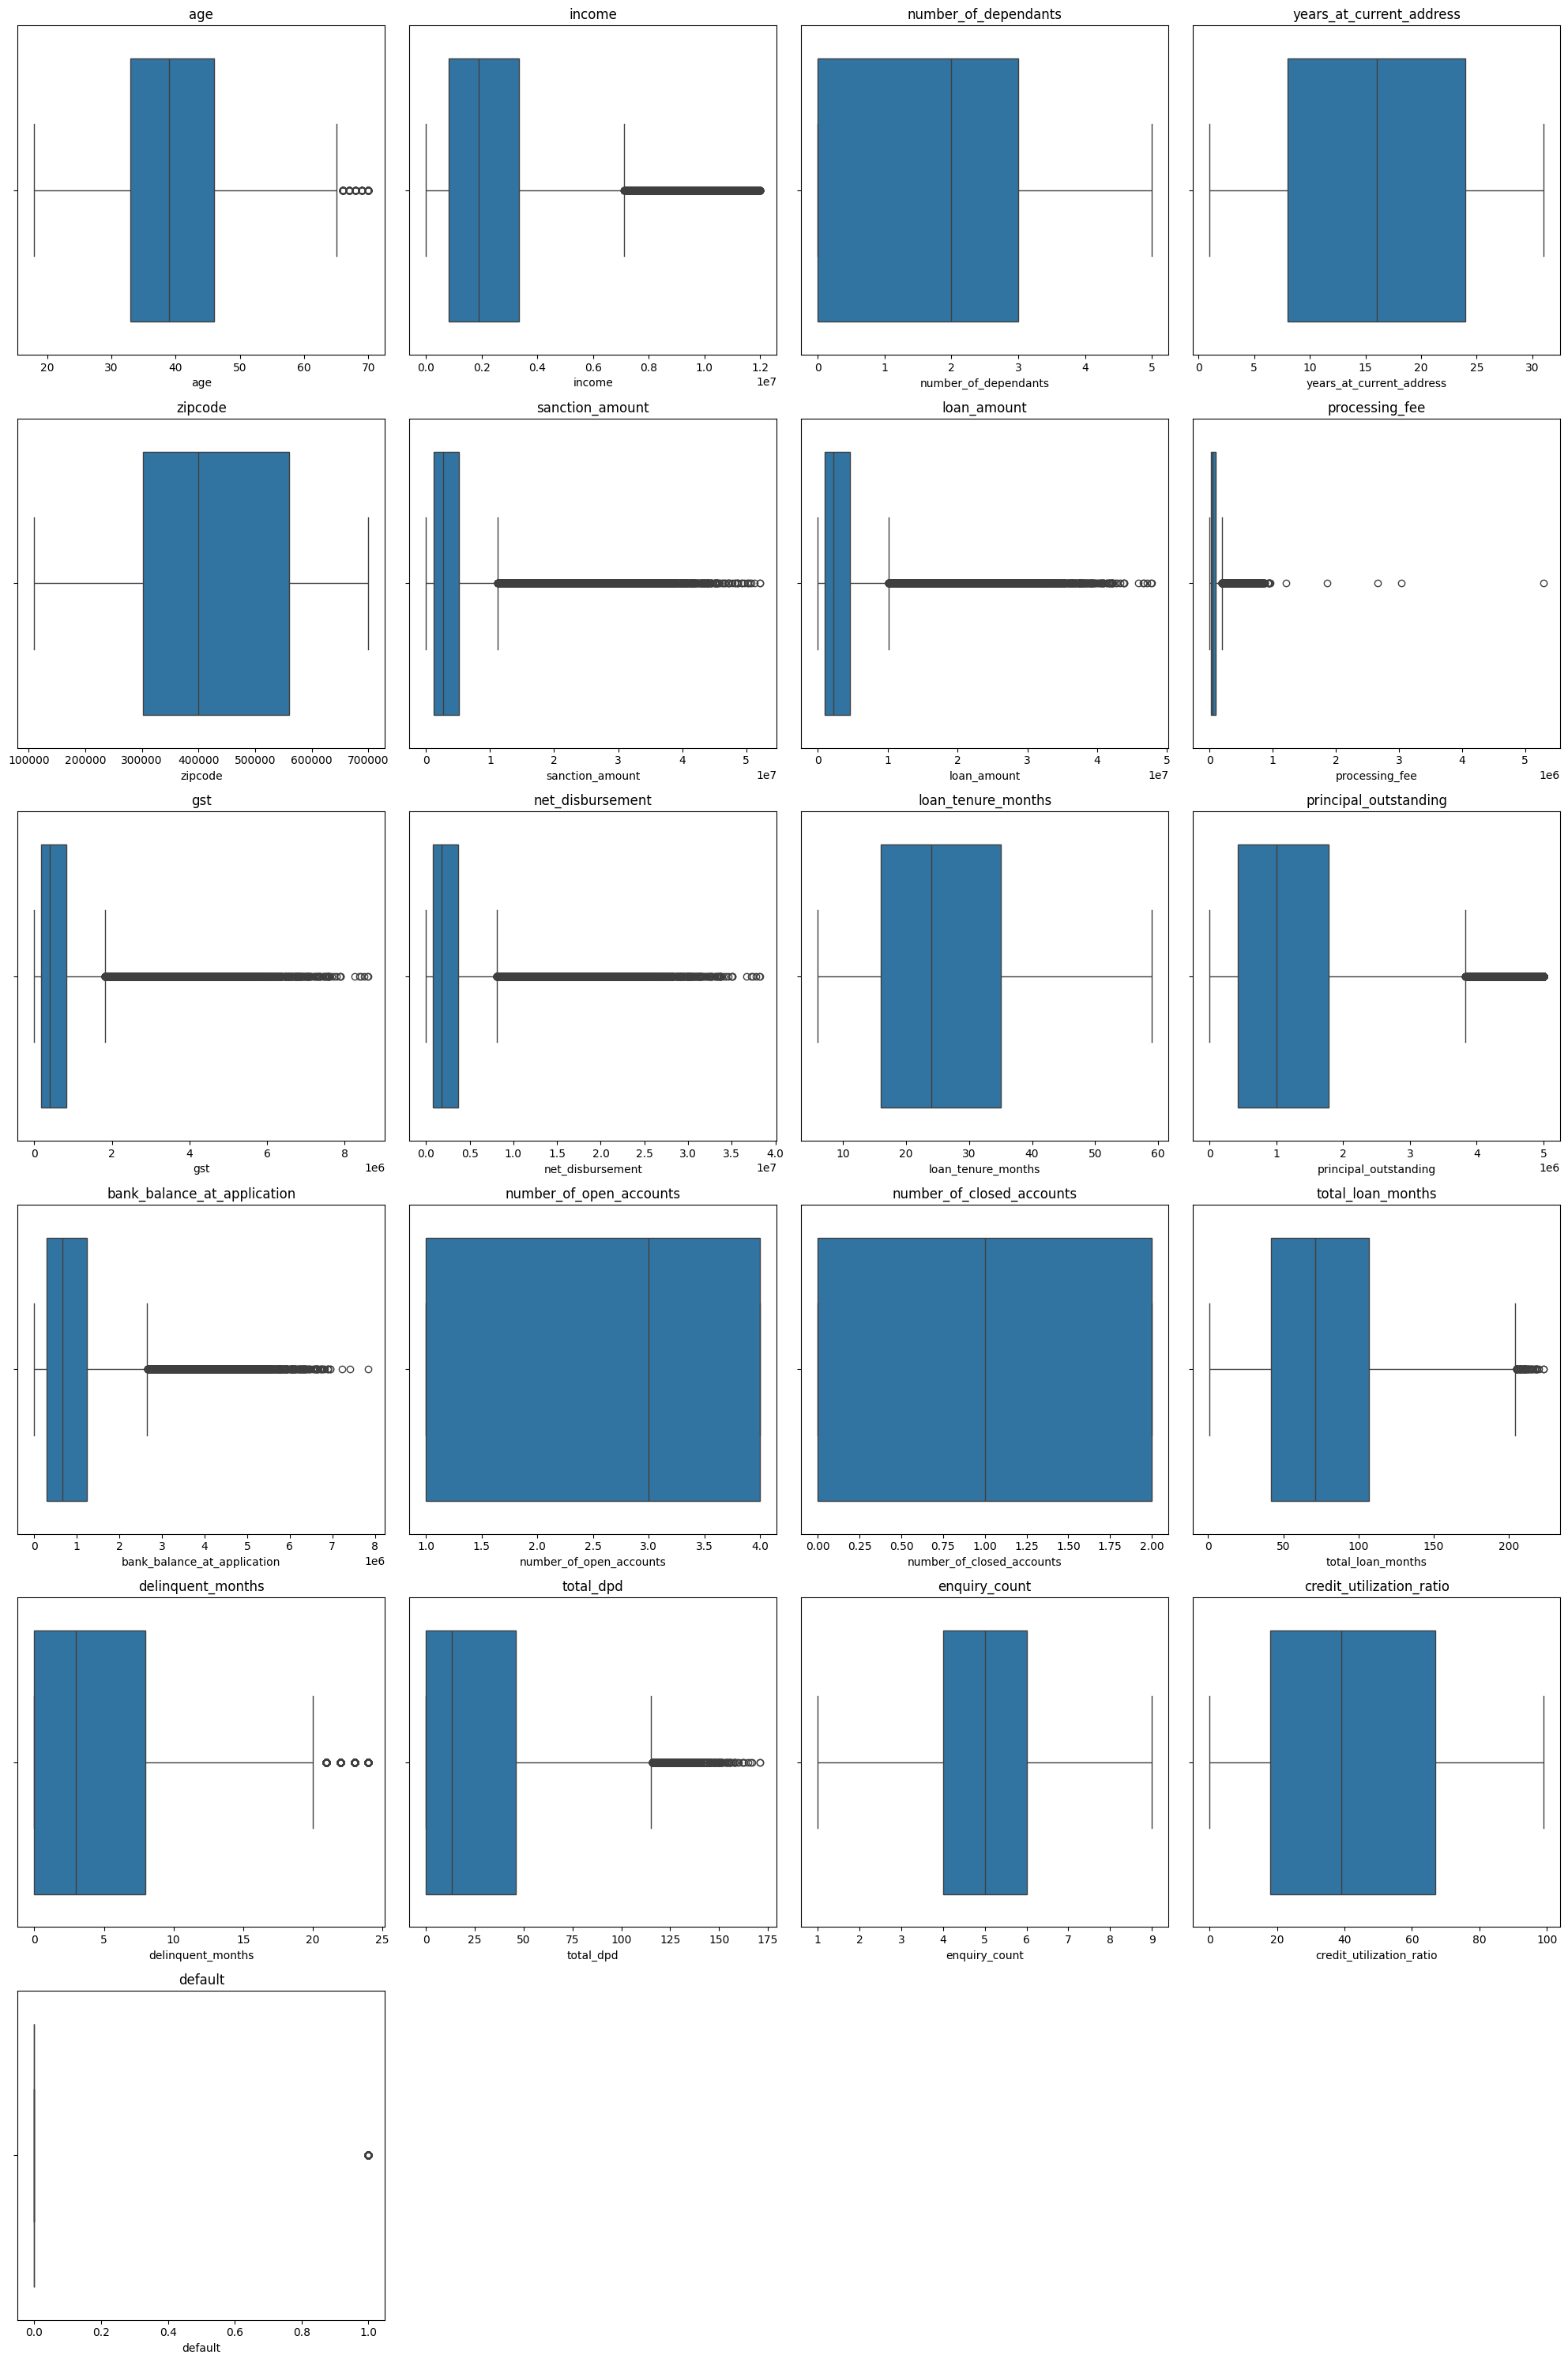

In [211]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.boxplot(
        x=df_train[col],
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

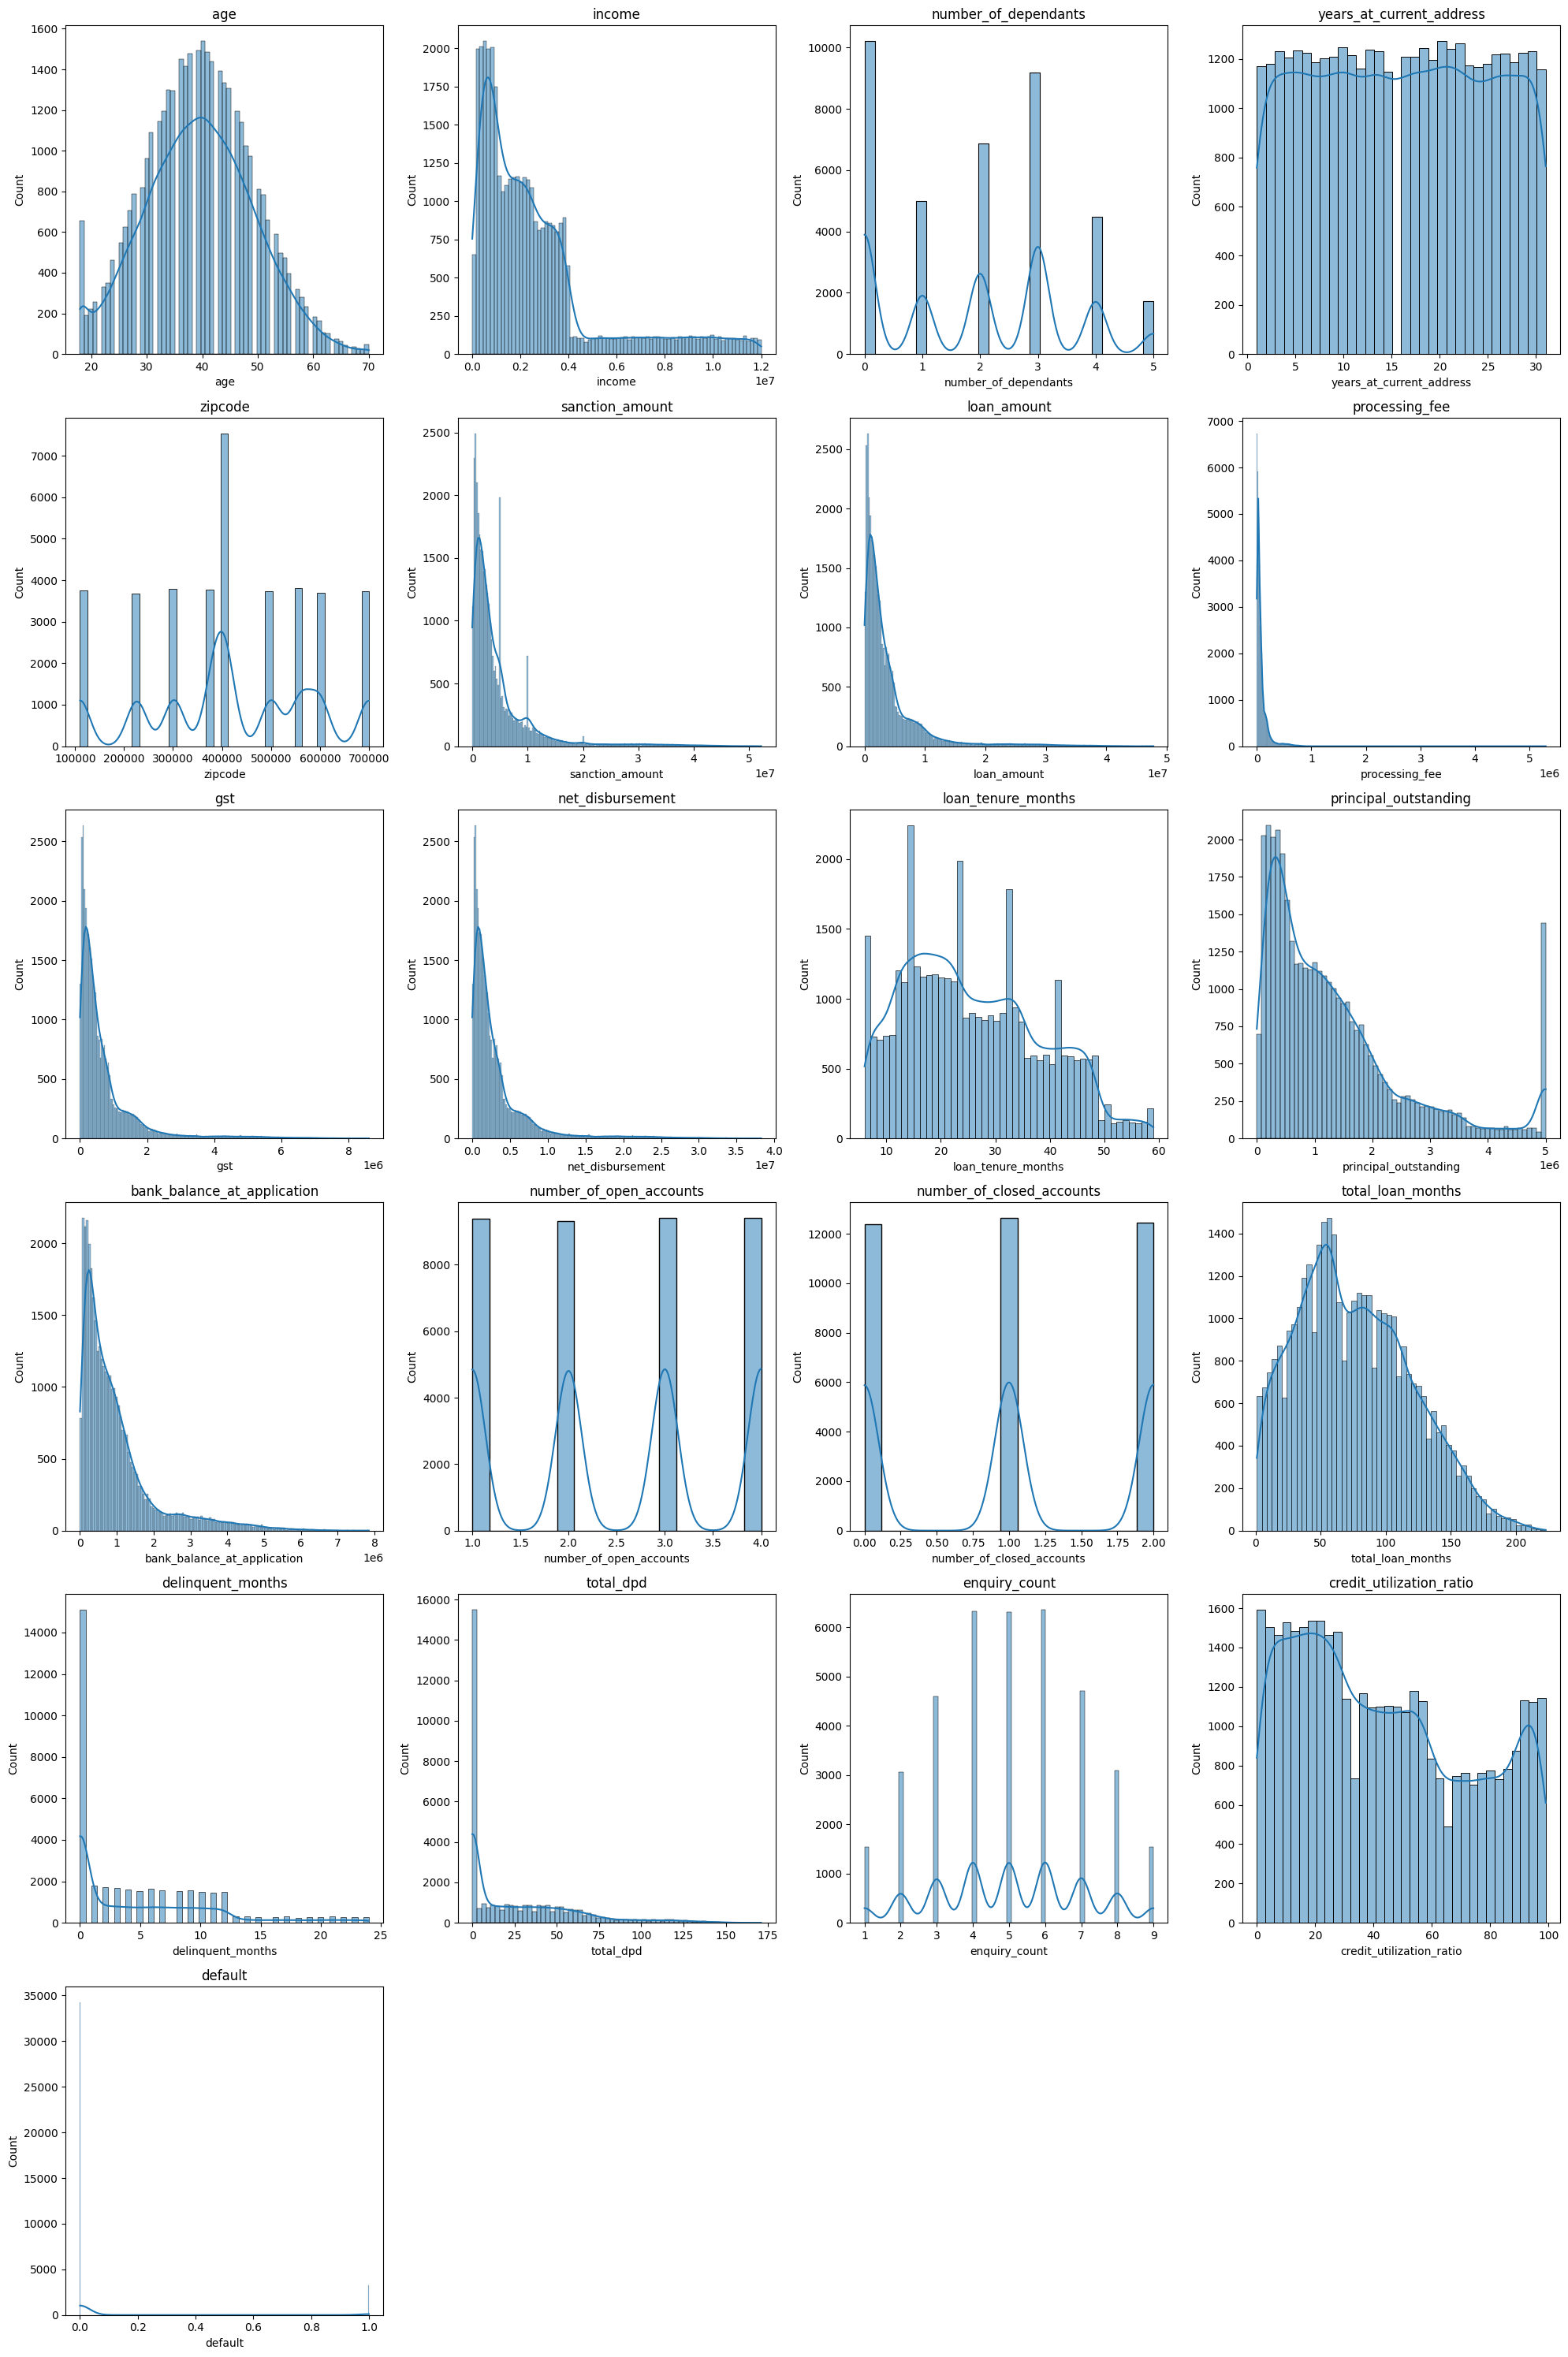

In [212]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train.select_dtypes(include='number').columns

n_cols = 4
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(20, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    sns.histplot(
        df_train[col],
        kde=True,
        ax=axes[i]
    )
    axes[i].set_title(col)

# Remove empty subplots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [213]:
# from the graph -> i need to work on bureau and loans dataset 
df_train[df_train['sanction_amount']==df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
45224,C45225,43,M,Married,Salaried,0,4,Mortgage,30,Chennai,...,2024-01-30,2024-02-27,3,1,112,10,53,7,30,0
2278,C02279,46,M,Married,Self-Employed,0,2,Rented,26,Pune,...,2019-10-15,2019-11-03,4,2,129,0,0,7,15,0
11092,C11093,39,F,Single,Salaried,0,0,Rented,17,Chennai,...,2020-09-01,2020-09-08,2,1,67,0,0,5,12,0
46640,C46641,28,F,Married,Salaried,0,4,Rented,24,Jaipur,...,2024-03-22,2024-04-08,2,0,73,0,0,6,30,0
47428,C47429,27,M,Single,Self-Employed,0,0,Owned,19,Lucknow,...,2024-04-19,2024-05-13,4,0,99,15,87,4,37,0
13356,C13357,34,F,Single,Self-Employed,0,1,Owned,2,Delhi,...,2020-11-23,2020-12-21,2,2,63,22,125,3,28,0
27457,C27458,48,F,Married,Self-Employed,0,3,Owned,5,Pune,...,2022-04-21,2022-05-12,4,1,72,0,0,7,89,0


In [214]:
7*100/73493

0.00952471663967997

In [215]:
df_train['processing_fee'].describe().apply(lambda x: f"{x:,.2f}")

count       37,500.00
mean        80,290.68
std        113,128.14
min              0.00
25%         19,220.00
50%         44,600.00
75%         92,420.00
max      5,293,543.52
Name: processing_fee, dtype: object

In [216]:
max_fee = df_train['processing_fee'].max()

df_train[df_train['processing_fee'] == max_fee][['loan_amount','processing_fee']]

,loan_amount,processing_fee
9898,3626000,5.293544e+06


In [217]:
df_train[df_train['processing_fee']>df_train['loan_amount']]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default
23981,C23982,33,F,Single,Self-Employed,1790000,0,Rented,7,Kolkata,...,2021-12-15,2022-01-14,4,2,154,9,31,6,26,0
28174,C28175,36,F,Single,Self-Employed,1123000,1,Rented,31,Hyderabad,...,2022-05-18,2022-06-05,3,0,111,8,41,3,62,0
47089,C47090,37,M,Married,Self-Employed,1892000,2,Rented,13,Jaipur,...,2024-04-07,2024-04-15,3,0,112,5,33,3,32,0
29305,C29306,52,M,Married,Self-Employed,3839000,2,Owned,11,Delhi,...,2022-06-28,2022-07-21,2,2,42,11,65,3,2,0
9898,C09899,56,M,Married,Self-Employed,8948000,5,Owned,16,Ahmedabad,...,2020-07-19,2020-08-11,2,1,51,1,5,3,92,0


In [218]:
df_train_1 = df_train[(df_train['processing_fee']/df_train['loan_amount'])<0.03].copy()
df_test = df_test[(df_test['processing_fee']/df_test['loan_amount'])<0.03].copy()



In [219]:
df_train_1[df_train_1.disbursal_date >= df_train_1.installment_start_dt]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


In [220]:
cat_cols = [
    'gender',
    'marital_status',
    'employment_status',
    'residence_type',
    'city',
    'state',
    'zipcode',
    'loan_purpose',
    'loan_type',
    'default'
]



In [221]:
for col in cat_cols:
    print(col,"---->",df_train_1[col].unique())

gender ----> ['M' 'F']
marital_status ----> ['Married' 'Single']
employment_status ----> ['Self-Employed' 'Salaried']
residence_type ----> ['Owned' 'Mortgage' 'Rented']
city ----> ['Hyderabad' 'Mumbai' 'Chennai' 'Bangalore' 'Pune' 'Kolkata' 'Ahmedabad'
 'Delhi' 'Lucknow' 'Jaipur']
state ----> ['Telangana' 'Maharashtra' 'Tamil Nadu' 'Karnataka' 'West Bengal'
 'Gujarat' 'Delhi' 'Uttar Pradesh' 'Rajasthan']
zipcode ----> [500001 400001 600001 560001 411001 700001 380001 110001 226001 302001]
loan_purpose ----> ['Home' 'Education' 'Personal' 'Auto' 'Personaal']
loan_type ----> ['Secured' 'Unsecured']
default ----> [0 1]


In [222]:
df_train_1['loan_purpose'] = df_train_1['loan_purpose'].replace('Personaal','Personal')
df_test['loan_purpose'] = df_test['loan_purpose'].replace('Personaal','Personal')

In [223]:
df_train_1[(df_train_1.gst/df_train_1.loan_amount)>0.2]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,disbursal_date,installment_start_dt,number_of_open_accounts,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default


In [224]:
df_train_1[df_train_1.net_disbursement>df_train_1.loan_amount].shape

(0, 33)

<h3 align ='center' style = "color:yellow">Exploratory Data Analysis </h3>

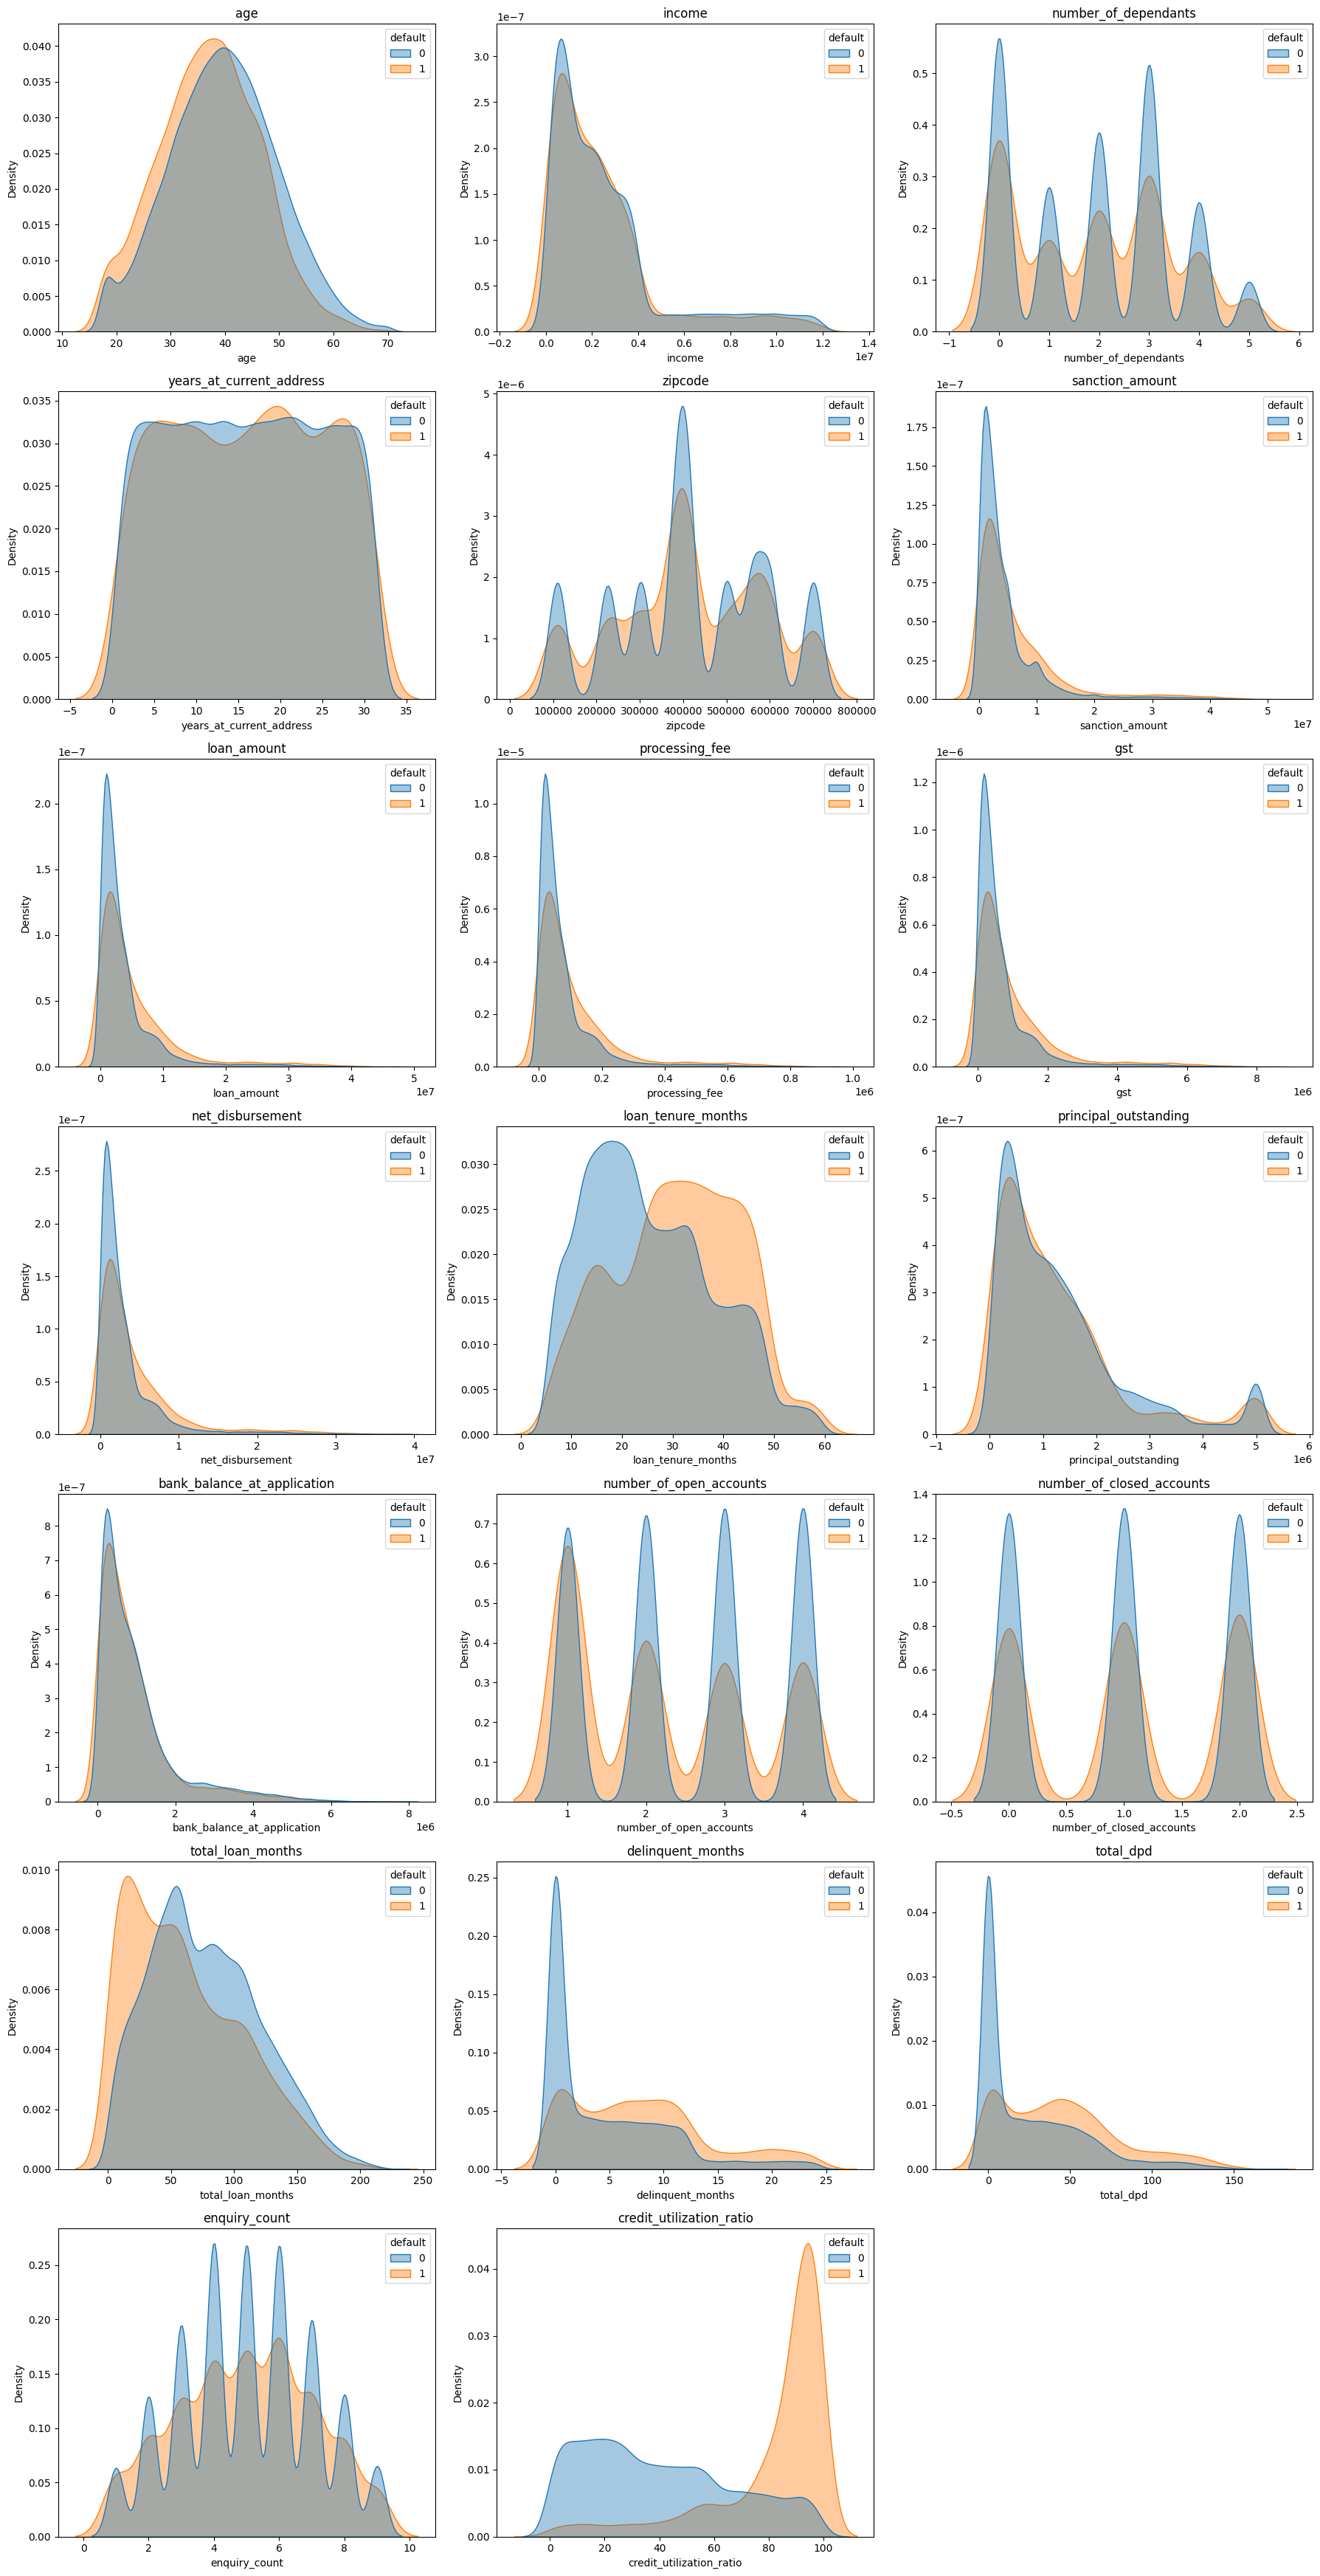

In [225]:
import matplotlib.pyplot as plt
import seaborn as sns
import math

num_cols = df_train_1.select_dtypes(include='number').columns
num_cols = [col for col in num_cols if col != 'default']

n_cols = 3
n_rows = math.ceil(len(num_cols) / n_cols)

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(18, 5 * n_rows)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):

    sns.kdeplot(
        data=df_train_1,
        x=col,
        hue='default',
        fill=True,
        common_norm=False,
        alpha=0.4,
        ax=axes[i]
    )

    axes[i].set_title(col)

# Remove empty plots
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

#### INSIGHTS :
1. young population less default 
2. young population lower credit_utilisation_Ratio
3. young population have lower dpd and delinquent_months
4. young population take lown for less tenure
(age,credit_utilisation_ratio,dpt,delinquent_months,total_months_tenure strong predictors)


<h1 align ='center' style = "color:yellow" >FEATURE ENGINEERING <h1/>

In [226]:
df_train_1['loan_to_income'] = round((df_train_1.loan_amount / df_train_1.income),2)
df_test['loan_to_income'] = round((df_test.loan_amount / df_test.income),2)
df_train_1[['loan_amount','income','loan_to_income']]

,loan_amount,income,loan_to_income
12746,23442000,11327000,2.07
32495,1149000,715000,1.61
43675,11296000,3195000,3.54
9040,1695000,1500000,1.13
13077,905000,1817000,0.50
...,...,...,...
28515,1420000,2470000,0.57
5558,2753000,2472000,1.11
45236,4479000,1329000,3.37
49228,1890000,1274000,1.48


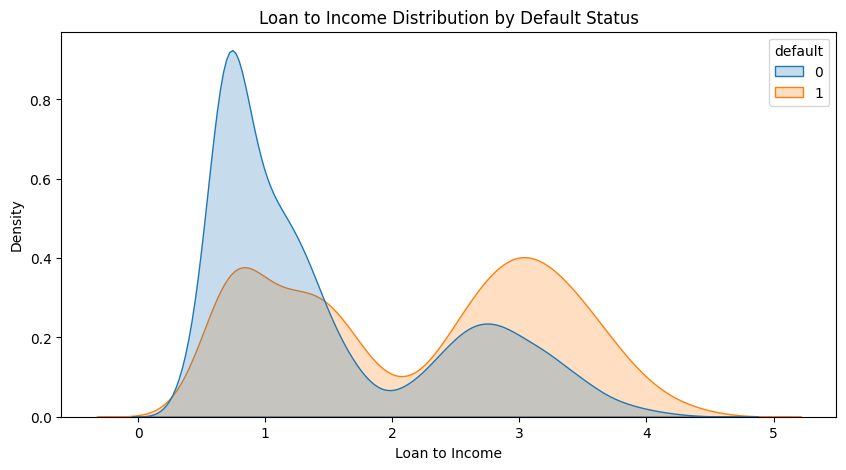

In [227]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='loan_to_income',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('Loan to Income Distribution by Default Status')
plt.xlabel('Loan to Income')
plt.ylabel('Density')
plt.show()

In [228]:
df_train_1['deliquency_ratio'] = round((df_train_1.delinquent_months / df_train_1.total_loan_months),2)
df_test['deliquency_ratio'] = round((df_test.delinquent_months / df_test.total_loan_months),2)


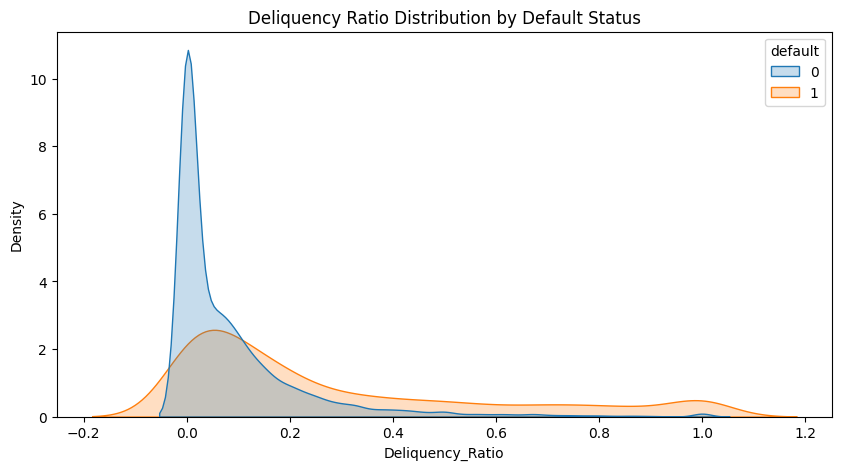

In [229]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='deliquency_ratio',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('Deliquency Ratio Distribution by Default Status')
plt.xlabel('Deliquency_Ratio')
plt.ylabel('Density')
plt.show()

In [230]:
df_train_1['avg_dpd_per_deliquency'] = np.where(df_train_1['delinquent_months'] != 0,
(df_train_1['total_dpd'] / df_train_1['delinquent_months']).round(2),0)


df_test['avg_dpd_per_deliquency'] = np.where(df_test['delinquent_months'] != 0,
(df_test['total_dpd'] / df_test['delinquent_months']).round(2),0)

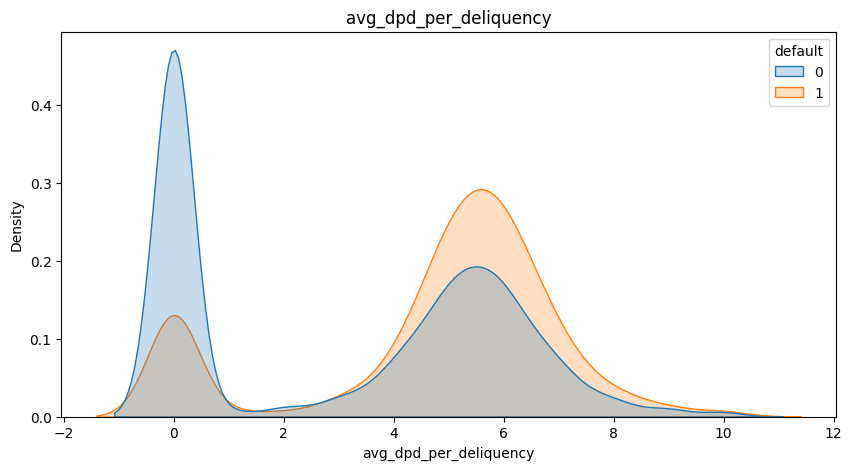

In [231]:
plt.figure(figsize=(10,5))

sns.kdeplot(
    data=df_train_1,
    x='avg_dpd_per_deliquency',
    hue='default',
    fill=True,
    common_norm=False
)

plt.title('avg_dpd_per_deliquency')
plt.xlabel('avg_dpd_per_deliquency')
plt.ylabel('Density')
plt.show()

In [232]:
df_train_1[df_train_1.loan_to_income==0]

,cust_id,age,gender,marital_status,employment_status,income,number_of_dependants,residence_type,years_at_current_address,city,...,number_of_closed_accounts,total_loan_months,delinquent_months,total_dpd,enquiry_count,credit_utilization_ratio,default,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency


In [233]:
df_train_1.columns

Index(['cust_id', 'age', 'gender', 'marital_status', 'employment_status',
       'income', 'number_of_dependants', 'residence_type',
       'years_at_current_address', 'city', 'state', 'zipcode', 'loan_id',
       'loan_purpose', 'loan_type', 'sanction_amount', 'loan_amount',
       'processing_fee', 'gst', 'net_disbursement', 'loan_tenure_months',
       'principal_outstanding', 'bank_balance_at_application',
       'disbursal_date', 'installment_start_dt', 'number_of_open_accounts',
       'number_of_closed_accounts', 'total_loan_months', 'delinquent_months',
       'total_dpd', 'enquiry_count', 'credit_utilization_ratio', 'default',
       'loan_to_income', 'deliquency_ratio', 'avg_dpd_per_deliquency'],
      dtype='object')

In [234]:
df_train_2 = df_train_1.drop(['cust_id','loan_id','disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)

df_test = df_test.drop(['cust_id','loan_id','disbursal_date', 'installment_start_dt', 'loan_amount', 'income', 
                              'total_loan_months', 'delinquent_months', 'total_dpd'], axis=1)

In [235]:
df_train_2.columns

Index(['age', 'gender', 'marital_status', 'employment_status',
       'number_of_dependants', 'residence_type', 'years_at_current_address',
       'city', 'state', 'zipcode', 'loan_purpose', 'loan_type',
       'sanction_amount', 'processing_fee', 'gst', 'net_disbursement',
       'loan_tenure_months', 'principal_outstanding',
       'bank_balance_at_application', 'number_of_open_accounts',
       'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'default', 'loan_to_income',
       'deliquency_ratio', 'avg_dpd_per_deliquency'],
      dtype='object')

In [236]:
df_train_2.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37488 entries, 12746 to 37784
Data columns (total 27 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          37488 non-null  int64  
 1   gender                       37488 non-null  object 
 2   marital_status               37488 non-null  object 
 3   employment_status            37488 non-null  object 
 4   number_of_dependants         37488 non-null  int64  
 5   residence_type               37488 non-null  object 
 6   years_at_current_address     37488 non-null  int64  
 7   city                         37488 non-null  object 
 8   state                        37488 non-null  object 
 9   zipcode                      37488 non-null  int64  
 10  loan_purpose                 37488 non-null  object 
 11  loan_type                    37488 non-null  object 
 12  sanction_amount              37488 non-null  int64  
 13  processing_fee   

In [237]:
df_train_2.select_dtypes(['int','float'])

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,default,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency
12746,59,3,30,500001,33121000,468840.0,4219560,18753600,28,5000000,4820526,4,2,4,36,0,2.07,0.13,5.90
32495,44,0,27,400001,1175000,22980.0,206820,919200,50,467229,216697,3,1,5,5,0,1.61,0.06,6.20
43675,38,0,26,600001,11409000,225920.0,2033280,9036800,32,1656773,1383842,1,1,4,0,0,3.54,0.22,5.58
9040,42,2,30,560001,2336000,33900.0,305100,1356000,40,1023442,626203,3,0,8,87,0,1.13,0.00,0.00
13077,58,4,29,411001,1167000,18100.0,162900,724000,15,651599,585099,1,2,1,71,0,0.50,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,70,0,20,700001,1562000,28400.0,255600,1136000,12,1022399,501594,2,0,5,13,0,0.57,0.00,0.00
5558,39,0,26,700001,3208000,55060.0,495540,2202400,32,1123466,587429,1,0,4,44,0,1.11,0.27,5.14
45236,39,4,10,411001,4804000,89580.0,806220,3583200,38,913243,517025,4,2,6,97,1,3.37,0.08,4.00
49228,33,2,26,600001,2451000,37800.0,340200,1512000,37,635515,475147,2,1,6,25,0,1.48,0.00,0.00


In [238]:
X_train = df_train_2.drop('default', axis='columns')
y_train = df_train_2['default']

# ------------------------------

X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

In [239]:
X_train = df_train_2.drop('default', axis='columns')
y_train = df_train_2['default']

from sklearn.preprocessing import MinMaxScaler

cols_to_scale = X_train.select_dtypes(['int64', 'float64']).columns

scaler = MinMaxScaler()

X_train[cols_to_scale] = scaler.fit_transform(X_train[cols_to_scale])
X_train.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency
count,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000,37488.00000,37488.000000,37488.000000,37488.000000,37488.000000,37488.000000
mean,0.414240,0.388903,0.499918,0.523517,0.088840,0.082513,0.082513,0.082513,0.376631,0.261615,0.123550,0.500925,0.50056,0.501077,0.438653,0.294312,0.103331,0.328416
std,0.189590,0.307182,0.297364,0.286491,0.120117,0.112480,0.112480,0.112480,0.234860,0.244461,0.133275,0.373040,0.40701,0.253666,0.296902,0.228030,0.173017,0.290672
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020555,0.018963,0.018963,0.018963,0.188679,0.077988,0.034205,0.000000,0.00000,0.375000,0.181818,0.110070,0.000000,0.000000
50%,0.403846,0.400000,0.500000,0.491525,0.049364,0.045516,0.045516,0.045516,0.339623,0.193870,0.082515,0.666667,0.50000,0.500000,0.393939,0.201405,0.040000,0.433000
75%,0.538462,0.600000,0.766667,0.762712,0.098027,0.095555,0.095555,0.095555,0.547170,0.352418,0.155192,1.000000,1.00000,0.625000,0.676768,0.505855,0.130000,0.574250
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000


In [240]:
X_test = df_test.drop('default', axis='columns')
y_test = df_test['default']

X_test[cols_to_scale] = scaler.transform(X_test[cols_to_scale])
X_test.describe()

,age,number_of_dependants,years_at_current_address,zipcode,sanction_amount,processing_fee,gst,net_disbursement,loan_tenure_months,principal_outstanding,bank_balance_at_application,number_of_open_accounts,number_of_closed_accounts,enquiry_count,credit_utilization_ratio,loan_to_income,deliquency_ratio,avg_dpd_per_deliquency
count,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000,12497.000000
mean,0.415001,0.384892,0.502697,0.525015,0.089218,0.082800,0.082800,0.082800,0.375092,0.264632,0.124944,0.497293,0.500440,0.501470,0.436038,0.293038,0.106069,0.333862
std,0.188773,0.306871,0.298103,0.286179,0.120844,0.112877,0.112877,0.112877,0.233792,0.245290,0.134708,0.372576,0.407226,0.253618,0.295418,0.226176,0.173125,0.289688
min,0.000000,0.000000,0.000000,0.000000,-0.000019,-0.000126,-0.000126,-0.000126,0.000000,0.000163,0.000668,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.288462,0.000000,0.233333,0.325424,0.020958,0.019387,0.019387,0.019387,0.188679,0.079715,0.034167,0.000000,0.000000,0.375000,0.181818,0.112412,0.000000,0.000000
50%,0.423077,0.400000,0.500000,0.510169,0.050189,0.046249,0.046249,0.046249,0.339623,0.198239,0.084024,0.333333,0.500000,0.500000,0.393939,0.201405,0.040000,0.440000
75%,0.538462,0.600000,0.766667,0.762712,0.097422,0.094927,0.094927,0.094927,0.547170,0.356914,0.157792,0.666667,1.000000,0.625000,0.676768,0.498829,0.130000,0.575000
max,1.000000,1.000000,1.000000,1.000000,0.981249,0.963717,0.963717,0.963717,1.000000,1.000000,0.939154,1.000000,1.000000,1.000000,1.000000,1.004684,1.000000,1.000000


In [241]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

def calculate_vif(data):
    vif_df = pd.DataFrame()
    vif_df['Column'] = data.columns
    vif_df['VIF'] = [variance_inflation_factor(data.values,i) for i in range(data.shape[1])]
    return vif_df

In [242]:
calculate_vif(X_train[cols_to_scale])

,Column,VIF
0,age,5.700659
1,number_of_dependants,2.730314
2,years_at_current_address,3.422566
3,zipcode,3.797538
4,sanction_amount,101.086587
5,processing_fee,inf
6,gst,inf
7,net_disbursement,inf
8,loan_tenure_months,6.180577
9,principal_outstanding,16.326472


In [243]:
features_to_drop_vif = ['sanction_amount', 'processing_fee', 'gst', 'net_disbursement','principal_outstanding']


X_train_1 = X_train.drop(features_to_drop_vif, axis='columns')
numeric_columns = X_train_1.select_dtypes(['int64', 'float64']).columns
numeric_columns

Index(['age', 'number_of_dependants', 'years_at_current_address', 'zipcode',
       'loan_tenure_months', 'bank_balance_at_application',
       'number_of_open_accounts', 'number_of_closed_accounts', 'enquiry_count',
       'credit_utilization_ratio', 'loan_to_income', 'deliquency_ratio',
       'avg_dpd_per_deliquency'],
      dtype='object')

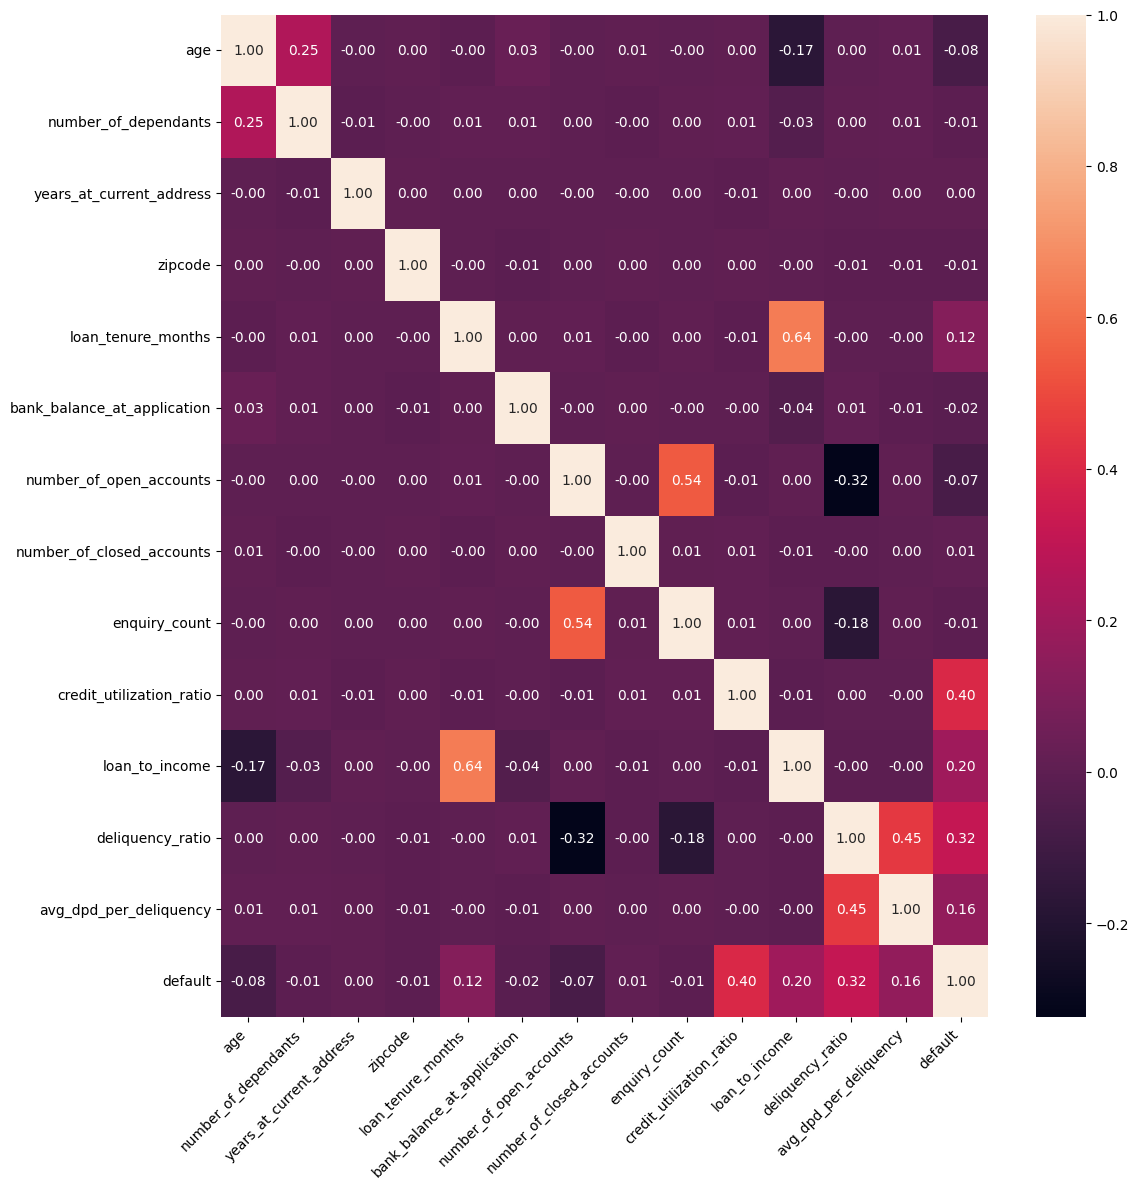

In [244]:
plt.figure(figsize=(12,12))
cm = df_train_2[numeric_columns.append(pd.Index(['default']))].corr()
sns.heatmap(cm, annot=True, fmt='0.2f')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

### WOE AND IV


In [245]:
def calculate_woe_iv(df,feature,target):
    grouped = df.groupby(feature)[target].agg(['count','sum'])
    grouped = grouped.rename(columns ={'count':'total','sum':'defaulters'})
    grouped['non_defaulters'] = grouped['total'] - grouped['defaulters']
    total_defaulters = grouped['defaulters'].sum()
    total_non_defaulters = grouped['non_defaulters'].sum()
    grouped['defaulters_pct'] = grouped['defaulters']/total_defaulters
    grouped['non_defaulters_pct'] = grouped['non_defaulters']/total_non_defaulters
    grouped['woe'] = np.where((grouped['defaulters_pct'] != 0) &(grouped['non_defaulters_pct'] != 0),np.log(grouped['defaulters_pct'] /grouped['non_defaulters_pct']),0)
    grouped['iv'] = (grouped['defaulters_pct'] - grouped['non_defaulters_pct'])*grouped['woe']
    total_iv = grouped['iv'].sum()

    return grouped,total_iv

grouped, total_iv = calculate_woe_iv(pd.concat([X_train_1, y_train],axis=1), 'loan_purpose', 'default')
grouped.round(2)   

  

,total,defaulters,non_defaulters,defaulters_pct,non_defaulters_pct,woe,iv
loan_purpose,,,,,,,
Auto,7447,327,7120,0.10,0.21,-0.72,0.08
Education,5620,559,5061,0.17,0.15,0.16,0.00
Home,11304,1734,9570,0.54,0.28,0.66,0.17
Personal,13117,603,12514,0.19,0.37,-0.67,0.12


In [246]:
iv_values = {}
for feature in X_train_1.columns:
    if(X_train_1[feature].dtype=='object'):
        _,iv = calculate_woe_iv(pd.concat([X_train_1,y_train],axis=1),feature,'default')
    else:
        X_binned = pd.cut(X_train_1[feature],bins=10,labels=False)
        _,iv = calculate_woe_iv(pd.concat([X_binned,y_train],axis=1),feature,'default')
    iv_values[feature] = round(float(iv), 4)
iv_values    

{'age': 0.0891,
 'gender': 0.0005,
 'marital_status': 0.0011,
 'employment_status': 0.004,
 'number_of_dependants': 0.0019,
 'residence_type': 0.2467,
 'years_at_current_address': 0.0021,
 'city': 0.0019,
 'state': 0.0019,
 'zipcode': 0.0017,
 'loan_purpose': 0.3691,
 'loan_type': 0.1632,
 'loan_tenure_months': 0.2189,
 'bank_balance_at_application': 0.0063,
 'number_of_open_accounts': 0.0846,
 'number_of_closed_accounts': 0.0012,
 'enquiry_count': 0.0079,
 'credit_utilization_ratio': 2.353,
 'loan_to_income': 0.4764,
 'deliquency_ratio': 0.7132,
 'avg_dpd_per_deliquency': 0.4018}

In [247]:
iv_df = pd.DataFrame(list(iv_values.items()), columns=['Feature', 'IV'])
iv_df = iv_df.sort_values(by='IV', ascending=False)
iv_df

,Feature,IV
17,credit_utilization_ratio,2.3530
19,deliquency_ratio,0.7132
18,loan_to_income,0.4764
20,avg_dpd_per_deliquency,0.4018
10,loan_purpose,0.3691
5,residence_type,0.2467
12,loan_tenure_months,0.2189
11,loan_type,0.1632
0,age,0.0891
14,number_of_open_accounts,0.0846


In [248]:
selected_features_df = iv_df[iv_df.IV >0.02]
selected_features_df

,Feature,IV
17,credit_utilization_ratio,2.3530
19,deliquency_ratio,0.7132
18,loan_to_income,0.4764
20,avg_dpd_per_deliquency,0.4018
10,loan_purpose,0.3691
5,residence_type,0.2467
12,loan_tenure_months,0.2189
11,loan_type,0.1632
0,age,0.0891
14,number_of_open_accounts,0.0846


In [249]:
selected_features = selected_features_df['Feature'].tolist()
selected_features

['credit_utilization_ratio',
 'deliquency_ratio',
 'loan_to_income',
 'avg_dpd_per_deliquency',
 'loan_purpose',
 'residence_type',
 'loan_tenure_months',
 'loan_type',
 'age',
 'number_of_open_accounts']

In [250]:
X_train_reduced = X_train_1[selected_features]
X_test_reduced = X_test[selected_features]
X_train_reduced

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_purpose,residence_type,loan_tenure_months,loan_type,age,number_of_open_accounts
12746,0.363636,0.13,0.414520,0.590,Home,Owned,0.415094,Secured,0.788462,1.000000
32495,0.050505,0.06,0.306792,0.620,Education,Owned,0.830189,Secured,0.500000,0.666667
43675,0.000000,0.22,0.758782,0.558,Home,Mortgage,0.490566,Secured,0.384615,0.000000
9040,0.878788,0.00,0.194379,0.000,Education,Mortgage,0.641509,Secured,0.461538,0.666667
13077,0.717172,0.00,0.046838,0.000,Personal,Owned,0.169811,Unsecured,0.769231,0.000000
...,...,...,...,...,...,...,...,...,...,...
28515,0.131313,0.00,0.063232,0.000,Personal,Owned,0.113208,Unsecured,1.000000,0.333333
5558,0.444444,0.27,0.189696,0.514,Auto,Rented,0.490566,Secured,0.403846,0.000000
45236,0.979798,0.08,0.718970,0.400,Home,Owned,0.603774,Secured,0.403846,1.000000
49228,0.252525,0.00,0.276347,0.000,Education,Owned,0.584906,Secured,0.288462,0.333333


In [251]:
X_train_encoded = pd.get_dummies(X_train_reduced, drop_first=True)
X_train_encoded

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
12746,0.363636,0.13,0.414520,0.590,0.415094,0.788462,1.000000,False,True,False,True,False,False
32495,0.050505,0.06,0.306792,0.620,0.830189,0.500000,0.666667,True,False,False,True,False,False
43675,0.000000,0.22,0.758782,0.558,0.490566,0.384615,0.000000,False,True,False,False,False,False
9040,0.878788,0.00,0.194379,0.000,0.641509,0.461538,0.666667,True,False,False,False,False,False
13077,0.717172,0.00,0.046838,0.000,0.169811,0.769231,0.000000,False,False,True,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...
28515,0.131313,0.00,0.063232,0.000,0.113208,1.000000,0.333333,False,False,True,True,False,True
5558,0.444444,0.27,0.189696,0.514,0.490566,0.403846,0.000000,False,False,False,False,True,False
45236,0.979798,0.08,0.718970,0.400,0.603774,0.403846,1.000000,False,True,False,True,False,False
49228,0.252525,0.00,0.276347,0.000,0.584906,0.288462,0.333333,True,False,False,True,False,False


In [252]:
X_test_encoded = pd.get_dummies(X_test_reduced, drop_first=True)
X_test_encoded

,credit_utilization_ratio,deliquency_ratio,loan_to_income,avg_dpd_per_deliquency,loan_tenure_months,age,number_of_open_accounts,loan_purpose_Education,loan_purpose_Home,loan_purpose_Personal,residence_type_Owned,residence_type_Rented,loan_type_Unsecured
19205,0.989899,0.00,0.550351,0.000,0.754717,0.346154,0.333333,False,True,False,True,False,False
15514,0.323232,0.00,0.220141,0.000,0.226415,0.480769,1.000000,True,False,False,True,False,False
30367,0.828283,0.00,0.180328,0.000,0.547170,0.230769,0.666667,False,False,False,True,False,False
35347,0.484848,0.02,0.571429,0.700,0.754717,0.365385,1.000000,False,True,False,True,False,False
41814,0.979798,0.11,0.407494,0.636,0.716981,0.576923,0.666667,False,True,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...
29297,0.525253,0.05,0.250585,0.280,0.433962,0.173077,0.666667,False,False,False,True,False,False
20567,0.050505,0.00,0.672131,0.000,0.547170,0.423077,0.000000,False,True,False,False,True,False
681,0.545455,0.06,0.002342,0.350,0.169811,0.192308,0.333333,False,False,True,False,True,True
33682,0.858586,0.00,0.784543,0.000,0.584906,0.250000,0.000000,False,True,False,True,False,False


In [253]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [254]:
X_test_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [255]:
y_train.value_counts(normalize=True)*100

default
0    91.402582
1     8.597418
Name: proportion, dtype: float64

In [256]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve,
    precision_recall_curve, f1_score, fbeta_score
)

from imblearn.over_sampling import SMOTE

import joblib
import warnings
warnings.filterwarnings('ignore')

## RIGHT NOW WE ARE NOT DEALING WITH CLASS IMBALANCE

In [257]:
# claude

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

model = LogisticRegression()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.72      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



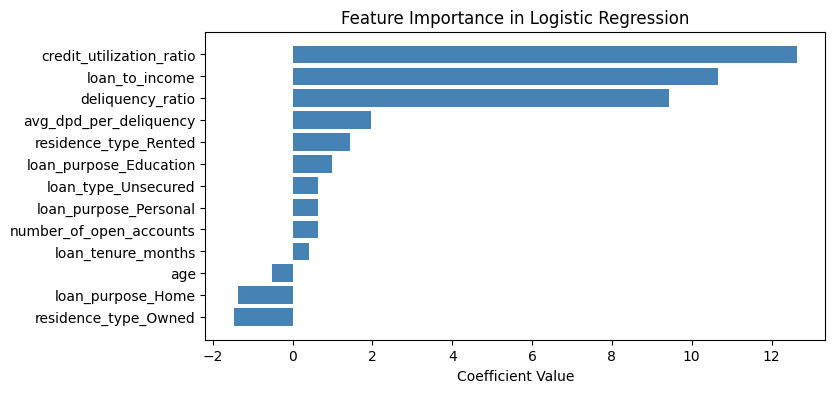

In [258]:
feature_importance = model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [259]:
from sklearn.ensemble import RandomForestClassifier

model = RandomForestClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.97      0.99      0.98     11423
           1       0.85      0.71      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.91      0.85      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [260]:
from xgboost import XGBClassifier

model = XGBClassifier()
model.fit(X_train_encoded, y_train)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.82      0.76      0.79      1074

    accuracy                           0.97     12497
   macro avg       0.90      0.87      0.88     12497
weighted avg       0.96      0.97      0.96     12497



In [261]:
# RANDOMIZED SEARCH CV FOR LOGISTIC REGRESSION 
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'C': np.logspace(-4, 4, 20),  # Logarithmically spaced values from 10^-4 to 10^4
    'solver': ['lbfgs', 'saga', 'liblinear', 'newton-cg']   # Algorithm to use in the optimization problem
}

# Create the Logistic Regression model
log_reg = LogisticRegression(max_iter=10000)  # Increased max_iter for convergence

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=log_reg,
    param_distributions=param_dist,
    n_iter=50,  # Number of parameter settings that are sampled
    scoring='f1',
    cv=3,  # 5-fold cross-validation
    verbose=2,
    random_state=42,  # Set a random state for reproducibility
    n_jobs=-1  # Use all available cores
)

# Fit the RandomizedSearchCV to the training data
random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 50 candidates, totalling 150 fits
Best Parameters: {'solver': 'lbfgs', 'C': np.float64(1438.44988828766)}
Best Score: 0.7571414051836808
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.99      0.98     11423
           1       0.83      0.74      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.90      0.86      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [262]:
# RANDOMISED SEARCH CV FOR XG BOOST
from scipy.stats import uniform, randint
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 150, 200, 250, 300],
    'max_depth': [3, 4, 5, 6, 7, 8, 9, 10],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3],
    'subsample': [0.6, 0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.6, 0.7, 0.8, 0.9, 1.0],
    'scale_pos_weight': [1, 2, 3, 5, 7, 10],
    'reg_alpha': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0],  # L1 regularization term
    'reg_lambda': [0.01, 0.1, 0.5, 1.0, 5.0, 10.0]  # L2 regularization term
}

xgb = XGBClassifier()

random_search = RandomizedSearchCV(estimator=xgb, param_distributions=param_dist, n_iter=100,
                                   scoring='f1', cv=3, verbose=1, n_jobs=-1, random_state=42)

random_search.fit(X_train_encoded, y_train)

# Print the best parameters and best score
print(f"Best Parameters: {random_search.best_params_}")
print(f"Best Score: {random_search.best_score_}")

best_model = random_search.best_estimator_
y_pred = best_model.predict(X_test_encoded)
print("Classification Report:")
print(classification_report(y_test, y_pred))

Fitting 3 folds for each of 100 candidates, totalling 300 fits
Best Parameters: {'subsample': 0.6, 'scale_pos_weight': 2, 'reg_lambda': 0.5, 'reg_alpha': 1.0, 'n_estimators': 150, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best Score: 0.7864684299368956
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.98      0.98     11423
           1       0.78      0.82      0.80      1074

    accuracy                           0.96     12497
   macro avg       0.88      0.90      0.89     12497
weighted avg       0.97      0.96      0.96     12497



### USING SMOTE TOMEK FOR DEALING WITH CLASS IMBALANCE


In [263]:
from imblearn.combine import SMOTETomek

smt = SMOTETomek(random_state=42)
X_train_smt, y_train_smt = smt.fit_resample(X_train_encoded, y_train)
y_train_smt.value_counts()

default
0    34201
1    34201
Name: count, dtype: int64

In [264]:
model = LogisticRegression()
model.fit(X_train_smt, y_train_smt)

y_pred = model.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [265]:
#USING OPTUNA TO GET BEST PARAMETERS FOR LOGISTIC REGRESSION AND XGBOOST 
import optuna
from sklearn.metrics import make_scorer, f1_score
from sklearn.model_selection import cross_val_score

In [266]:
# Define the objective function for Optuna
def objective(trial):
    param = {
        'C': trial.suggest_float('C', 1e-4, 1e4, log=True),  # Logarithmically spaced values
        'solver': trial.suggest_categorical('solver', ['lbfgs', 'liblinear', 'saga', 'newton-cg']),  # Solvers
        'tol': trial.suggest_float('tol', 1e-6, 1e-1, log=True),  # Logarithmically spaced values for tolerance
        'class_weight': trial.suggest_categorical('class_weight', [None, 'balanced'])  # Class weights
    }

    model = LogisticRegression(**param, max_iter=10000)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_logistic = optuna.create_study(direction='maximize')
study_logistic.optimize(objective, n_trials=50)

[I 2026-06-16 02:28:02,574] A new study created in memory with name: no-name-c4227e0c-32b1-4fd8-a2c4-0ab88c0e46d9
[I 2026-06-16 02:28:02,766] Trial 0 finished with value: 0.940536995060392 and parameters: {'C': 0.20635568984478103, 'solver': 'newton-cg', 'tol': 0.006653601265894719, 'class_weight': 'balanced'}. Best is trial 0 with value: 0.940536995060392.
[I 2026-06-16 02:28:03,057] Trial 1 finished with value: 0.945689051190555 and parameters: {'C': 7823.234816179933, 'solver': 'newton-cg', 'tol': 1.1247351184256954e-06, 'class_weight': None}. Best is trial 1 with value: 0.945689051190555.
[I 2026-06-16 02:28:03,522] Trial 2 finished with value: 0.945689051190555 and parameters: {'C': 764.8475540198335, 'solver': 'saga', 'tol': 5.11913955771489e-06, 'class_weight': None}. Best is trial 1 with value: 0.945689051190555.
[I 2026-06-16 02:28:03,759] Trial 3 finished with value: 0.9457465672707907 and parameters: {'C': 9.06045399806671, 'solver': 'liblinear', 'tol': 0.0001324474340121986

In [267]:
print('Best trial:')
trial = study_logistic.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_model_logistic = LogisticRegression(**study_logistic.best_params)
best_model_logistic.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_logistic.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.9460213964099436
  Params: 
    C: 12.926958911020876
    solver: liblinear
    tol: 0.016193571910446392
    class_weight: None
              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [268]:
# XG BOOST
# Define the objective function for Optuna
def objective(trial):
    param = {
        'objective': 'binary:logistic',
        'eval_metric': 'logloss',
        'verbosity': 0,
        'booster': 'gbtree',
        'lambda': trial.suggest_float('lambda', 1e-3, 10.0, log=True),
        'alpha': trial.suggest_float('alpha', 1e-3, 10.0, log=True),
        'subsample': trial.suggest_float('subsample', 0.4, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.4, 1.0),
        'max_depth': trial.suggest_int('max_depth', 3, 10),
        'eta': trial.suggest_float('eta', 0.01, 0.3),
        'gamma': trial.suggest_float('gamma', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'max_delta_step': trial.suggest_int('max_delta_step', 0, 10)
    }

    model = XGBClassifier(**param)
    
    # Calculate the cross-validated f1_score
    f1_scorer = make_scorer(f1_score, average='macro')
    scores = cross_val_score(model, X_train_smt, y_train_smt, cv=3, scoring=f1_scorer, n_jobs=-1)
    
    return np.mean(scores)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective, n_trials=50)

[I 2026-06-16 02:28:11,739] A new study created in memory with name: no-name-4c1ead83-9d5e-4dba-a154-9db93160ac24
[I 2026-06-16 02:28:12,502] Trial 0 finished with value: 0.9623684303168333 and parameters: {'lambda': 0.5604874870885606, 'alpha': 0.8936977512026326, 'subsample': 0.9371235779953628, 'colsample_bytree': 0.9500039215519368, 'max_depth': 8, 'eta': 0.06959211925344401, 'gamma': 8.855495426895404, 'scale_pos_weight': 4.415183114874879, 'min_child_weight': 10, 'max_delta_step': 6}. Best is trial 0 with value: 0.9623684303168333.
[I 2026-06-16 02:28:13,127] Trial 1 finished with value: 0.9611809109610016 and parameters: {'lambda': 0.11050511100710315, 'alpha': 0.004435185130301337, 'subsample': 0.8422335274836807, 'colsample_bytree': 0.41536938192496153, 'max_depth': 6, 'eta': 0.1867065434829634, 'gamma': 0.7879033485701636, 'scale_pos_weight': 7.686503967174035, 'min_child_weight': 1, 'max_delta_step': 5}. Best is trial 0 with value: 0.9623684303168333.
[I 2026-06-16 02:28:13,

In [269]:
print('Best trial:')
trial = study_xgb.best_trial
print('  F1-score: {}'.format(trial.value))
print('  Params: ')
for key, value in trial.params.items():
    print('    {}: {}'.format(key, value))
    
best_params = study_xgb.best_params
best_model_xgb = XGBClassifier(**best_params)
best_model_xgb.fit(X_train_smt, y_train_smt)

# Evaluate on the test set
y_pred = best_model_xgb.predict(X_test_encoded)

report = classification_report(y_test, y_pred)
print(report)

Best trial:
  F1-score: 0.97623811520728
  Params: 
    lambda: 0.07480859256235202
    alpha: 0.16705809923763343
    subsample: 0.7608916890415887
    colsample_bytree: 0.6599787373238382
    max_depth: 10
    eta: 0.2480961620156894
    gamma: 0.030830805438124206
    scale_pos_weight: 1.662441804019624
    min_child_weight: 3
    max_delta_step: 9
              precision    recall  f1-score   support

           0       0.98      0.97      0.98     11423
           1       0.73      0.83      0.78      1074

    accuracy                           0.96     12497
   macro avg       0.86      0.90      0.88     12497
weighted avg       0.96      0.96      0.96     12497



In [270]:
# LOGISTIC REGRESSION LOOKS BETTER FOR THIS PROJECT SO WE WILL GO WITH LOGISTIC REGRESSION

In [271]:
y_pred = best_model_logistic.predict(X_test_encoded)
report = classification_report(y_test, y_pred)
print(report)

              precision    recall  f1-score   support

           0       0.99      0.93      0.96     11423
           1       0.55      0.94      0.70      1074

    accuracy                           0.93     12497
   macro avg       0.77      0.94      0.83     12497
weighted avg       0.96      0.93      0.94     12497



In [272]:
from sklearn.metrics import roc_curve

probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, probabilities)

fpr[:5], tpr[:5], thresholds[:5]

(array([0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 8.75426771e-05,
        8.75426771e-05]),
 array([0.        , 0.0009311 , 0.16759777, 0.16759777, 0.17877095]),
 array([       inf, 1.        , 0.99888087, 0.9988756 , 0.99874157]))

In [273]:
from sklearn.metrics import auc

area = auc(fpr, tpr)
area

0.9836882072188963

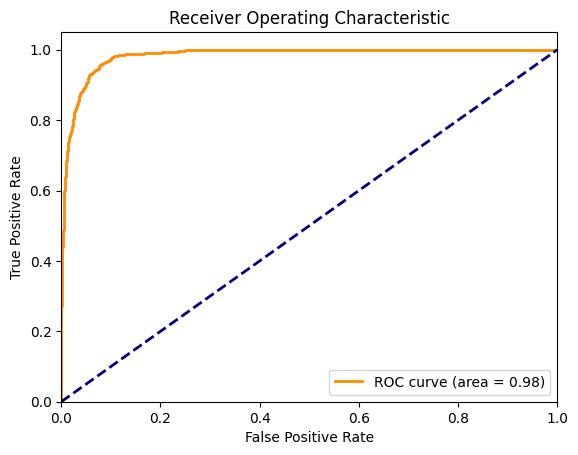

In [274]:
plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % area)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

### MODEL EVALUATION : USING KS STATIC,RANK ORDERING AND GINI COEFF

In [275]:
probabilities = best_model_logistic.predict_proba(X_test_encoded)[:,1]
final_df = pd.DataFrame({"default_truth":y_test,"default_prob":probabilities})
final_df

,default_truth,default_prob
19205,0,0.560244
15514,0,0.000031
30367,0,0.009457
35347,0,0.010838
41814,1,0.923904
...,...,...
29297,0,0.000997
20567,0,0.000163
681,0,0.004479
33682,0,0.811665


In [276]:
final_df['deciles'] = pd.qcut(final_df['default_prob'],10,labels=False,duplicates='drop')
final_df

,default_truth,default_prob,deciles
19205,0,0.560244,8
15514,0,0.000031,2
30367,0,0.009457,6
35347,0,0.010838,6
41814,1,0.923904,9
...,...,...,...
29297,0,0.000997,4
20567,0,0.000163,3
681,0,0.004479,5
33682,0,0.811665,9


In [277]:
final_df_2 = final_df.groupby('deciles').apply(lambda x: pd.Series(
    {
    'Min_Prob' : x['default_prob'].min(),
    'Max_Prob' : x['default_prob'].max(),
    'Event' : x['default_truth'].sum(),
    'Non_Events':x['default_truth'].count() - x['default_truth'].sum(),
    }
))
final_df_2.reset_index(inplace=True)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events
0,0,7.761711e-09,0.000003,0.0,1250.0
1,1,2.598533e-06,0.000017,0.0,1250.0
2,2,1.725750e-05,0.000076,0.0,1249.0
3,3,7.612782e-05,0.000336,0.0,1250.0
4,4,3.366934e-04,0.001475,0.0,1250.0
5,5,1.477020e-03,0.007227,0.0,1249.0
6,6,7.228412e-03,0.039918,6.0,1244.0
7,7,3.992032e-02,0.238734,10.0,1239.0
8,8,2.392713e-01,0.811347,159.0,1091.0
9,9,8.115712e-01,1.000000,899.0,351.0


In [278]:
final_df_2['Event_Rate'] = final_df_2.Event*100/(final_df_2.Event+final_df_2.Non_Events)
final_df_2['Non_Event_Rate'] = (final_df_2.Non_Events * 100)/(final_df_2.Event + final_df_2.Non_Events)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate
0,0,7.761711e-09,0.000003,0.0,1250.0,0.000000,100.000000
1,1,2.598533e-06,0.000017,0.0,1250.0,0.000000,100.000000
2,2,1.725750e-05,0.000076,0.0,1249.0,0.000000,100.000000
3,3,7.612782e-05,0.000336,0.0,1250.0,0.000000,100.000000
4,4,3.366934e-04,0.001475,0.0,1250.0,0.000000,100.000000
5,5,1.477020e-03,0.007227,0.0,1249.0,0.000000,100.000000
6,6,7.228412e-03,0.039918,6.0,1244.0,0.480000,99.520000
7,7,3.992032e-02,0.238734,10.0,1239.0,0.800641,99.199359
8,8,2.392713e-01,0.811347,159.0,1091.0,12.720000,87.280000
9,9,8.115712e-01,1.000000,899.0,351.0,71.920000,28.080000


In [279]:
final_df_2 =final_df_2.sort_values(by='deciles', ascending=False).reset_index(drop=True)
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate
0,9,8.115712e-01,1.000000,899.0,351.0,71.920000,28.080000
1,8,2.392713e-01,0.811347,159.0,1091.0,12.720000,87.280000
2,7,3.992032e-02,0.238734,10.0,1239.0,0.800641,99.199359
3,6,7.228412e-03,0.039918,6.0,1244.0,0.480000,99.520000
4,5,1.477020e-03,0.007227,0.0,1249.0,0.000000,100.000000
5,4,3.366934e-04,0.001475,0.0,1250.0,0.000000,100.000000
6,3,7.612782e-05,0.000336,0.0,1250.0,0.000000,100.000000
7,2,1.725750e-05,0.000076,0.0,1249.0,0.000000,100.000000
8,1,2.598533e-06,0.000017,0.0,1250.0,0.000000,100.000000
9,0,7.761711e-09,0.000003,0.0,1250.0,0.000000,100.000000


In [280]:
final_df_2['Cum_Event'] = final_df_2['Event'].cumsum()
final_df_2['Cum_Non_Event'] = final_df_2['Non_Events'].cumsum()
final_df_2


,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event
0,9,8.115712e-01,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0
1,8,2.392713e-01,0.811347,159.0,1091.0,12.720000,87.280000,1058.0,1442.0
2,7,3.992032e-02,0.238734,10.0,1239.0,0.800641,99.199359,1068.0,2681.0
3,6,7.228412e-03,0.039918,6.0,1244.0,0.480000,99.520000,1074.0,3925.0
4,5,1.477020e-03,0.007227,0.0,1249.0,0.000000,100.000000,1074.0,5174.0
5,4,3.366934e-04,0.001475,0.0,1250.0,0.000000,100.000000,1074.0,6424.0
6,3,7.612782e-05,0.000336,0.0,1250.0,0.000000,100.000000,1074.0,7674.0
7,2,1.725750e-05,0.000076,0.0,1249.0,0.000000,100.000000,1074.0,8923.0
8,1,2.598533e-06,0.000017,0.0,1250.0,0.000000,100.000000,1074.0,10173.0
9,0,7.761711e-09,0.000003,0.0,1250.0,0.000000,100.000000,1074.0,11423.0


In [281]:
final_df_2['Cum_Event_Rate'] = final_df_2['Cum_Event'] * 100/ final_df_2['Event'].sum()
final_df_2['Cum_Non_Event_Rate'] = final_df_2['Cum_Non_Event'] * 100 / final_df_2['Non_Events'].sum()
final_df_2


,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate
0,9,8.115712e-01,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0,83.705773,3.072748
1,8,2.392713e-01,0.811347,159.0,1091.0,12.720000,87.280000,1058.0,1442.0,98.510242,12.623654
2,7,3.992032e-02,0.238734,10.0,1239.0,0.800641,99.199359,1068.0,2681.0,99.441341,23.470192
3,6,7.228412e-03,0.039918,6.0,1244.0,0.480000,99.520000,1074.0,3925.0,100.000000,34.360501
4,5,1.477020e-03,0.007227,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581
5,4,3.366934e-04,0.001475,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416
6,3,7.612782e-05,0.000336,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250
7,2,1.725750e-05,0.000076,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331
8,1,2.598533e-06,0.000017,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165
9,0,7.761711e-09,0.000003,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000


In [282]:
final_df_2['KS'] = abs(final_df_2['Cum_Event_Rate'] - final_df_2['Cum_Non_Event_Rate'])
final_df_2

,deciles,Min_Prob,Max_Prob,Event,Non_Events,Event_Rate,Non_Event_Rate,Cum_Event,Cum_Non_Event,Cum_Event_Rate,Cum_Non_Event_Rate,KS
0,9,8.115712e-01,1.000000,899.0,351.0,71.920000,28.080000,899.0,351.0,83.705773,3.072748,80.633025
1,8,2.392713e-01,0.811347,159.0,1091.0,12.720000,87.280000,1058.0,1442.0,98.510242,12.623654,85.886588
2,7,3.992032e-02,0.238734,10.0,1239.0,0.800641,99.199359,1068.0,2681.0,99.441341,23.470192,75.971149
3,6,7.228412e-03,0.039918,6.0,1244.0,0.480000,99.520000,1074.0,3925.0,100.000000,34.360501,65.639499
4,5,1.477020e-03,0.007227,0.0,1249.0,0.000000,100.000000,1074.0,5174.0,100.000000,45.294581,54.705419
5,4,3.366934e-04,0.001475,0.0,1250.0,0.000000,100.000000,1074.0,6424.0,100.000000,56.237416,43.762584
6,3,7.612782e-05,0.000336,0.0,1250.0,0.000000,100.000000,1074.0,7674.0,100.000000,67.180250,32.819750
7,2,1.725750e-05,0.000076,0.0,1249.0,0.000000,100.000000,1074.0,8923.0,100.000000,78.114331,21.885669
8,1,2.598533e-06,0.000017,0.0,1250.0,0.000000,100.000000,1074.0,10173.0,100.000000,89.057165,10.942835
9,0,7.761711e-09,0.000003,0.0,1250.0,0.000000,100.000000,1074.0,11423.0,100.000000,100.000000,0.000000


In [283]:
gini_coefficient = 2 * area - 1

print("AUC:", area)
print("Gini Coefficient:", gini_coefficient)

AUC: 0.9836882072188963
Gini Coefficient: 0.9673764144377925


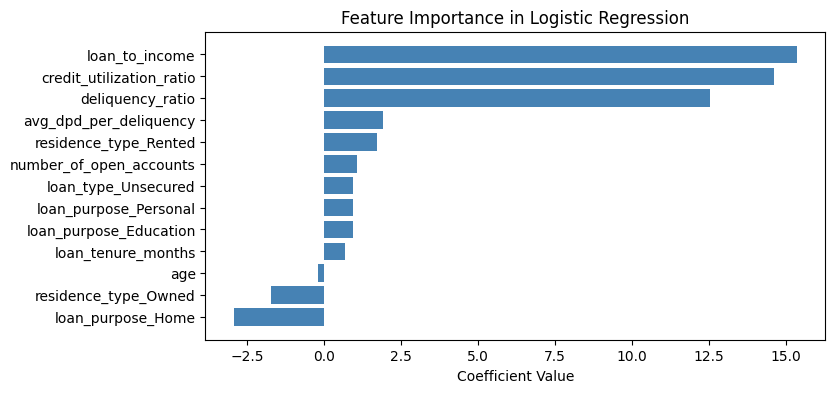

In [284]:
final_model = best_model_logistic

feature_importance = final_model.coef_[0]

# Create a DataFrame for easier handling
coef_df = pd.DataFrame(feature_importance, index=X_train_encoded.columns, columns=['Coefficients'])

# Sort the coefficients for better visualization
coef_df = coef_df.sort_values(by='Coefficients', ascending=True)

# Plotting
plt.figure(figsize=(8, 4))
plt.barh(coef_df.index, coef_df['Coefficients'], color='steelblue')
plt.xlabel('Coefficient Value')
plt.title('Feature Importance in Logistic Regression')
plt.show()

In [288]:
print(type(final_model))

<class 'sklearn.linear_model._logistic.LogisticRegression'>


In [289]:
# finally :
# X_train_encoded
# X_test_encoded
# y_train
# y_test
# final_model

In [290]:
X_train_encoded.columns

Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')

In [291]:
from joblib import dump

model_data = {
    'model': final_model,
    'features': X_train_encoded.columns,
    'scaler': scaler,
    'cols_to_scale': cols_to_scale
}
dump(model_data, 'Artifacts/model_data.joblib')

['Artifacts/model_data.joblib']

In [292]:
from joblib import load

obj = load("Artifacts/model_data.joblib")

print(obj.keys())
print(obj["features"])

dict_keys(['model', 'features', 'scaler', 'cols_to_scale'])
Index(['credit_utilization_ratio', 'deliquency_ratio', 'loan_to_income',
       'avg_dpd_per_deliquency', 'loan_tenure_months', 'age',
       'number_of_open_accounts', 'loan_purpose_Education',
       'loan_purpose_Home', 'loan_purpose_Personal', 'residence_type_Owned',
       'residence_type_Rented', 'loan_type_Unsecured'],
      dtype='object')


In [293]:
print(type(obj["scaler"]))

<class 'sklearn.preprocessing._data.MinMaxScaler'>


In [294]:
final_model.coef_, final_model.intercept_

(array([[14.63636998, 12.5567355 , 15.38244954,  1.91814674,  0.69661152,
         -0.17979464,  1.08235246,  0.94263644, -2.92677926,  0.94373738,
         -1.7056131 ,  1.72383847,  0.94373738]]),
 array([-18.90402629]))